In [22]:
# data 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.feature_selection import RFECV
import shap
import joblib
import umap
from sklearn.preprocessing import StandardScaler
le=LabelEncoder()
le_quad=LabelEncoder()
import time

In [3]:
# --models--
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV,LearningCurveDisplay,learning_curve,StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_auc_score,roc_curve,auc
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier


# pre-procces data


In [24]:
trainDf=pd.read_csv('iec104_custom_script_train_final.csv')
testDf=pd.read_csv('iec104_custom_script_test_final.csv')

quad_classes=['c_sc_na_1','c_sc_na_1_DoS','c_se_na_1','c_se_na_1_DoS']
train_quad_Df=trainDf[trainDf['Label'].isin(quad_classes)]
test_quad_Df=testDf[testDf['Label'].isin(quad_classes)]
X_train_quad=train_quad_Df.drop('Label',axis=1)
X_test_quad=test_quad_Df.drop('Label',axis=1)
le_quad.fit(train_quad_Df['Label'])
y_train_quad=le_quad.transform(train_quad_Df['Label'])
y_test_quad=le_quad.transform(test_quad_Df["Label"])
data_quad=pd.concat([train_quad_Df,test_quad_Df])
X_data_quad=data_quad.drop(['Label'],axis=1)
y_data_quad=le_quad.transform(data_quad["Label"])
trainDf['Label']=trainDf['Label'].replace(dict.fromkeys(quad_classes,'c_sc_and_c_se'))
testDf['Label']=testDf['Label'].replace(dict.fromkeys(quad_classes,'c_sc_and_c_se'))

le.fit(trainDf['Label'])
class_range=9
#drop the Labels from X_train/test and just keep the label on y_train/test
X_train=trainDf.drop('Label',axis=1)
y_train=le.transform(trainDf['Label'])
X_test=testDf.drop('Label',axis=1)
y_test=le.transform(testDf['Label'])
data=pd.concat([trainDf,testDf])
X_data=data.drop('Label',axis=1)
y_data=le.transform(data['Label'])

untouched_trainDf=pd.read_csv('iec104_custom_script_train_final.csv')
untouched_testDf=pd.read_csv('iec104_custom_script_test_final.csv')
le_un=LabelEncoder()
le_un.fit(untouched_trainDf['Label'])
X_train_un=untouched_trainDf.drop('Label',axis=1)
y_train_un=le_un.transform(untouched_trainDf['Label'])
X_test_un=untouched_testDf.drop('Label',axis=1)
y_test_un=le_un.transform(untouched_testDf['Label'])



# Creating the models.

In [ ]:
#--XGBoost--
Xgb_model=XGBClassifier(
    n_estimators=100,
    n_jobs=-1,
    objective='multi:softprob',
    num_class=class_range,
    random_state=63,
    device="cuda"
)
#--Lgbm--
Lgbm_model=LGBMClassifier(
    learning_rate=0.05,
    device="gpu",
    boosting_type='gbdt',
    objective='multiclass',
    num_class=class_range,
    num_leaves=6,
    max_depth=10,
    random_state=63
)
#--CatBoost--
CatBoost_model=CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    verbose=False,
    random_state=63,
    task_type="GPU",
)

rf_model = RandomForestClassifier(random_state=63, n_jobs=-1)

In [ ]:
#--XGBoost--
Xgb_model_quad=XGBClassifier(
    n_estimators=100,
    n_jobs=-1,
    objective='multi:softprob',
    num_class=4,
    random_state=63,
    device="cuda"
)
#--Lgbm--
Lgbm_model_quad=LGBMClassifier(
    learning_rate=0.05,
    device="gpu",
    boosting_type='gbdt',
    objective='multiclass',
    num_class=4,
    num_leaves=6,
    max_depth=10,
    random_state=63
)


rf_model_quad= RandomForestClassifier(random_state=63, n_jobs=-1)

In [ ]:
flat_xgb=XGBClassifier(
    max_depth=4,
    n_estimators=200,
    learning_rate=0.05,
    random_state=63  
)
flat_lgbm=LGBMClassifier(
    learning_rate=0.05,
    max_depth=10,
    num_leaves=127,
    objective='multiclass',
    random_state=63,
    verbose=-1,
    n_estimators=100,
    
)
flat_catboost=CatBoostClassifier(
    depth=7,
    iterations=200,
    learning_rate=0.1,
    loss_function='MultiClass',
    random_state=63
)

flat_rf= RandomForestClassifier(random_state=63, n_jobs=-1)

In [ ]:
param_grid_Xgb={
    'n_estimators':[100,200,300],
    'max_depth':[4,5,6,7,8],
    'learning_rate':[0.05,0.1,0.3],
}

In [ ]:
grid_search_Xgb=GridSearchCV(
    estimator=Xgb_model,
    param_grid=param_grid_Xgb,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_Xgb.fit(X_train,y_train)
print(f"best parameters= {grid_search_Xgb.best_params_}")
print(f'best cv score= {grid_search_Xgb.best_score_:.4f} ')

XGBOOST best parameters= {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
best cv score= 0.7668 

In [ ]:
grid_search_Xgb_quad=GridSearchCV(
    estimator=Xgb_model_quad,
    param_grid=param_grid_Xgb,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_Xgb_quad.fit(X_train_quad,y_train_quad)
print(f"best parameters= {grid_search_Xgb_quad.best_params_}")
print(f'best cv score= {grid_search_Xgb_quad.best_score_:.4f} ')

best parameters= {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
best cv score= 0.6473 


In [ ]:

grid_search_flat_xgb=GridSearchCV(
    estimator=flat_xgb,
    param_grid=param_grid_Xgb,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_flat_xgb.fit(X_train_un,y_train_un)
print(grid_search_flat_xgb.best_params_)
print(grid_search_flat_xgb.best_score_) 

Flat XGBOOST model {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
0.7035885357932861

In [ ]:
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'num_leaves': [15, 31, 63, 127], 
    'learning_rate': [0.05, 0.1, 0.3],
    'max_depth': [-1, 6, 10],      
}

In [ ]:
grid_search_Lgbm=GridSearchCV(
    estimator=Lgbm_model,
    param_grid=param_grid_lgbm,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_Lgbm.fit(X_train,y_train)
print(f"best parameters= {grid_search_Lgbm.best_params_}")
print(f'best cv score= {grid_search_Lgbm.best_score_:.4f} ')

LightGBM best parameters= {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 15}
best cv score= 0.7691 

In [ ]:
grid_search_Lgbm_quad=GridSearchCV(
    estimator=Lgbm_model_quad,
    param_grid=param_grid_lgbm,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_Lgbm_quad.fit(X_train_quad,y_train_quad)
print(f"best parameters= {grid_search_Lgbm_quad.best_params_}")
print(f'best cv score= {grid_search_Lgbm_quad.best_score_:.4f} ')


LGBM Quad best parameters= {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'num_leaves': 31}
best cv score= 0.6441 

In [ ]:
grid_search_flat_lgbm=GridSearchCV(
    estimator=flat_lgbm,
    param_grid=param_grid_lgbm,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
    verbose=0
)
grid_search_flat_lgbm.fit(X_train_un,y_train_un)
print(f"best parameters= {grid_search_flat_lgbm.best_params_}")
print(f'best cv score= {grid_search_flat_lgbm.best_score_:.4f} ')

Lgbm flat best parameters= {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 63}
best cv score= 0.7032 

In [ ]:

param_grid_CatBoost= {
    'iterations': [100,200,300],
    'depth': [4,5,6,7,8],
    'learning_rate': [0.05, 0.1,0.3]
}

In [ ]:
CatBoost_model=CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    random_state=63,
    task_type="GPU",
    verbose=0,
    allow_writing_files=False
)

In [ ]:
grid_search_CatBoost=GridSearchCV(
    estimator=CatBoost_model,
    param_grid=param_grid_CatBoost,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_CatBoost.fit(X_train,y_train)
print(f"best parameters= {grid_search_CatBoost.best_params_}")
print(f'best cv score= {grid_search_CatBoost.best_score_:.4f} ')

CatBoostbest best parameters= {'depth': 7, 'iterations': 300, 'learning_rate': 0.05}
best cv score= 0.7723 

In [ ]:
CatBoost_model_testing=CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='MultiClass',
    verbose=False,
    random_state=63,
    task_type="GPU",
    allow_writing_files=False
)


In [ ]:
grid_search_CatBoost_quad=GridSearchCV(
    estimator=CatBoost_model_testing,
    param_grid=param_grid_CatBoost,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_CatBoost_quad.fit(X_train_quad,y_train_quad)
print(f"best parameters= {grid_search_CatBoost_quad.best_params_}")
print(f'best cv score= {grid_search_CatBoost_quad.best_score_:.4f} ')

CatBoost Quad best parameters= {'depth': 5, 'iterations': 100, 'learning_rate': 0.05}
best cv score= 0.6654 

In [ ]:
grid_search_flat_catboost=GridSearchCV(
        estimator=flat_catboost,
        param_grid=param_grid_CatBoost,
        cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
        scoring='f1_macro',
        n_jobs=1,
)
grid_search_flat_catboost.fit(X_train_un,y_train_un)
print(f"best parameters= {grid_search_flat_catboost.best_params_}")
print(f'best cv score= {grid_search_flat_catboost.best_score_:.4f} ')

flat catboost best parameters= {'depth': 5, 'iterations': 300, 'learning_rate': 0.05}
best cv score= 0.7057 

In [ ]:
param_grid_rf = {
    'n_estimators': [200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 0.3],
}

In [ ]:
grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_rf.fit(X_train, y_train)
print(grid_search_rf.best_params_,grid_search_rf.best_score_)


rf best params {'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 2, 'n_estimators': 200} 
best cv score : 0.7741


In [ ]:
grid_search_rf_quad = GridSearchCV(
    estimator=rf_model_quad,
    param_grid=param_grid_rf,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_rf_quad.fit(X_train_quad, y_train_quad)
print (grid_search_rf_quad.best_params_,grid_search_rf_quad.best_score_)


rf quad best params: {'max_depth': 10, 'max_features': 0.3, 'min_samples_leaf': 2, 'n_estimators': 200} 
best cv score: 0.6404


In [ ]:
grid_search_flat_rf = GridSearchCV(
    estimator=flat_rf,
    param_grid=param_grid_rf,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=63),
    scoring='f1_macro',
    n_jobs=1,
)
grid_search_flat_rf.fit(X_train_un, y_train_un)
print(grid_search_flat_rf.best_params_,grid_search_flat_rf.best_score_)

flat rf best params: {'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 1, 'n_estimators': 200}
best cv score: 0.7081


In [ ]:
Xgb_model=grid_search_Xgb.best_estimator_
Lgbm_model=grid_search_Lgbm.best_estimator_
CatBoost_model=grid_search_CatBoost.best_estimator_

In [ ]:
Xgb_model_quad=grid_search_Xgb_quad.best_estimator_
Lgbm_model_quad=grid_search_Lgbm_quad.best_estimator_
Catboost_model_quad = grid_search_CatBoost_quad.best_estimator_

In [ ]:
rf_model       = grid_search_rf.best_estimator_
rf_model_quad  = grid_search_rf_quad.best_estimator_
flat_xgb       = grid_search_flat_xgb.best_estimator_
flat_lgbm      = grid_search_flat_lgbm.best_estimator_
flat_catboost  = grid_search_flat_catboost.best_estimator_
flat_rf        = grid_search_flat_rf.best_estimator_

# feature selection:


In [ ]:
rfecv_Lgbm=RFECV(
    estimator=Lgbm_model,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1,
    verbose=0
)
rfecv_Lgbm.fit(X_train,y_train)
print(f'selected features: {rfecv_Lgbm.n_features_}')

LightGBM selected features: 71

In [ ]:
rfecv_Lgbm_quad=RFECV(
    estimator=Lgbm_model_quad,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_Lgbm_quad.fit(X_train_quad,y_train_quad)
print(f'selected features: {rfecv_Lgbm_quad.n_features_}')

Light GBM QUAD selected features: 106

In [ ]:
rfecv_Xgb=RFECV(
    estimator=Xgb_model,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_Xgb.fit(X_train,y_train)
print(f'selected features: {rfecv_Xgb.n_features_}')


XGBOOST selected features: 36


In [ ]:
rfecv_Xgb_quad=RFECV(
    estimator=Xgb_model_quad,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_Xgb_quad.fit(X_train_quad,y_train_quad)
print(f'selected features: {rfecv_Xgb_quad.n_features_}')


XGB quad selected features: 26


In [ ]:
rfecv_CatBoost=RFECV(
    estimator=CatBoost_model,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_CatBoost.fit(X_train,y_train)

print(f'selected features: {rfecv_CatBoost.n_features_}')

CatBoost selected features: 111


In [ ]:
rfecv_CatBoost_quad=RFECV(
    estimator=Catboost_model_quad,
    step=5,
    cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
rfecv_CatBoost_quad.fit(X_train_quad,y_train_quad)
print(f'selected features: {rfecv_CatBoost_quad.n_features_}')

CatBoost quad selected features: 111



Used Joblib to load the results and not running again Recursive feature elimination with cross-validation and grid search to find selected features and best parameters for the models 

In [ ]:
joblib.dump(Xgb_model,        'Xgb_model_120.pkl')
joblib.dump(Lgbm_model,       'Lgbm_model_120.pkl')
joblib.dump(CatBoost_model,   'CatBoost_model_120.pkl')
joblib.dump(rf_model,         'rf_model_120.pkl')
joblib.dump(Xgb_model_quad,       'Xgb_model_quad_120.pkl')
joblib.dump(Lgbm_model_quad,      'Lgbm_model_quad_120.pkl')
joblib.dump(Catboost_model_quad,  'CatBoost_model_quad_120.pkl')
joblib.dump(rf_model_quad,        'rf_model_quad_120.pkl')
joblib.dump(flat_xgb,       'flat_xgb_120.pkl')
joblib.dump(flat_lgbm,      'flat_lgbm_120.pkl')
joblib.dump(flat_catboost,  'flat_catboost_120.pkl')
joblib.dump(flat_rf,        'flat_rf_120.pkl')

In [ ]:
joblib.dump(rfecv_Xgb,        'rfecv_Xgb_120.pkl')
joblib.dump(rfecv_Lgbm,       'rfecv_Lgbm_120.pkl')
joblib.dump(rfecv_CatBoost,   'rfecv_CatBoost_120.pkl')
joblib.dump(rfecv_Xgb_quad,       'rfecv_Xgb_quad_120.pkl')
joblib.dump(rfecv_Lgbm_quad,      'rfecv_Lgbm_quad_120.pkl')
joblib.dump(rfecv_CatBoost_quad,  'rfecv_CatBoost_quad_120.pkl')

In [9]:
rfecv_Xgb = joblib.load('rfecv_Xgb_120.pkl')
rfecv_Lgbm = joblib.load('rfecv_Lgbm_120.pkl')
rfecv_CatBoost = joblib.load('rfecv_CatBoost_120.pkl')

Xgb_model = joblib.load('Xgb_model_120.pkl')
Lgbm_model = joblib.load('Lgbm_model_120.pkl')
CatBoost_model = joblib.load('CatBoost_model_120.pkl')

rfecv_Xgb_quad = joblib.load('rfecv_Xgb_quad_120.pkl')
rfecv_Lgbm_quad = joblib.load('rfecv_Lgbm_quad_120.pkl')
rfecv_CatBoost_quad = joblib.load('rfecv_CatBoost_quad_120.pkl')

Xgb_model_quad = joblib.load('Xgb_model_quad_120.pkl')
Lgbm_model_quad = joblib.load('Lgbm_model_quad_120.pkl')
Catboost_model_quad = joblib.load('CatBoost_model_quad_120.pkl')

rf_model      = joblib.load('rf_model_120.pkl')
rf_model_quad = joblib.load('rf_model_quad_120.pkl')
flat_xgb      = joblib.load('flat_xgb_120.pkl')
flat_lgbm     = joblib.load('flat_lgbm_120.pkl')
flat_catboost = joblib.load('flat_catboost_120.pkl')
flat_rf       = joblib.load('flat_rf_120.pkl')



X_train_Feature_Selection_Xgb=X_train.loc[:,rfecv_Xgb.support_]
X_train_Feature_Selection_Lgbm= X_train.loc[:,rfecv_Lgbm.support_]
X_train_Feature_Selection_CatBoost=X_train.loc[:,rfecv_CatBoost.support_]



X_test_Feature_Selection_Xgb=X_test.loc[:,rfecv_Xgb.support_]
X_test_Feature_Selection_Lgbm= X_test.loc[:,rfecv_Lgbm.support_]
X_test_Feature_Selection_CatBoost=X_test.loc[:,rfecv_CatBoost.support_]


X_train_Feature_Selection_Xgb_quad = X_train_quad.loc[:, rfecv_Xgb_quad.support_]
X_train_Feature_Selection_Lgbm_quad = X_train_quad.loc[:, rfecv_Lgbm_quad.support_]
X_train_Feature_Selection_CatBoost_quad = X_train_quad.loc[:, rfecv_CatBoost_quad.support_]

X_test_Feature_Selection_Xgb_quad = X_test_quad.loc[:, rfecv_Xgb_quad.support_]
X_test_Feature_Selection_Lgbm_quad = X_test_quad.loc[:, rfecv_Lgbm_quad.support_]
X_test_Feature_Selection_CatBoost_quad = X_test_quad.loc[:, rfecv_CatBoost_quad.support_]



# Finding Feature importances and creating a model based only on those features.
#### plotting feature importance in horizontal bar chart with feature selection and all features 

In [10]:
models = [
    # (model, X, y_true, encoder, title)
    (Xgb_model,                            X_test,                                 y_test,      le,      "XGBoost"),
    (rfecv_Xgb.estimator_,                 X_test_Feature_Selection_Xgb,           y_test,      le,      "XGBoost RFECV"),
    (Xgb_model_quad,                       X_test_quad,                            y_test_quad, le_quad, "XGBoost QUAD"),
    (rfecv_Xgb_quad.estimator_,            X_test_Feature_Selection_Xgb_quad,      y_test_quad, le_quad, "XGBoost QUAD RFECV"),

    (Lgbm_model,                           X_test,                                 y_test,      le,      "LightGBM"),
    (rfecv_Lgbm.estimator_,                X_test_Feature_Selection_Lgbm,          y_test,      le,      "LightGBM RFECV"),
    (Lgbm_model_quad,                      X_test_quad,                            y_test_quad, le_quad, "LightGBM QUAD"),
    (rfecv_Lgbm_quad.estimator_,           X_test_Feature_Selection_Lgbm_quad,     y_test_quad, le_quad, "LightGBM QUAD RFECV"),

    (CatBoost_model,                       X_test,                                 y_test,      le,      "CatBoost"),
    (rfecv_CatBoost.estimator_,            X_test_Feature_Selection_CatBoost,      y_test,      le,      "CatBoost RFECV"),
    (Catboost_model_quad,                  X_test_quad,                            y_test_quad, le_quad, "CatBoost QUAD"),
    (rfecv_CatBoost_quad.estimator_,       X_test_Feature_Selection_CatBoost_quad, y_test_quad, le_quad, "CatBoost QUAD RFECV"),

    (rf_model,                             X_test,                                 y_test,      le,      "RandomForest"),
    (rf_model_quad,                        X_test_quad,                            y_test_quad, le_quad, "RandomForest QUAD"),

    (flat_xgb,                             X_test_un,                              y_test_un,   le_un,   "XGBoost FLAT"),
    (flat_lgbm,                            X_test_un,                              y_test_un,   le_un,   "LightGBM FLAT"),
    (flat_catboost,                        X_test_un,                              y_test_un,   le_un,   "CatBoost FLAT"),
    (flat_rf,                              X_test_un,                              y_test_un,   le_un,   "RandomForest FLAT"),
]



In [13]:
def functions(function):
    for model, X, y_true, enc, title in models:
        function(model, X, y_true, enc, title)


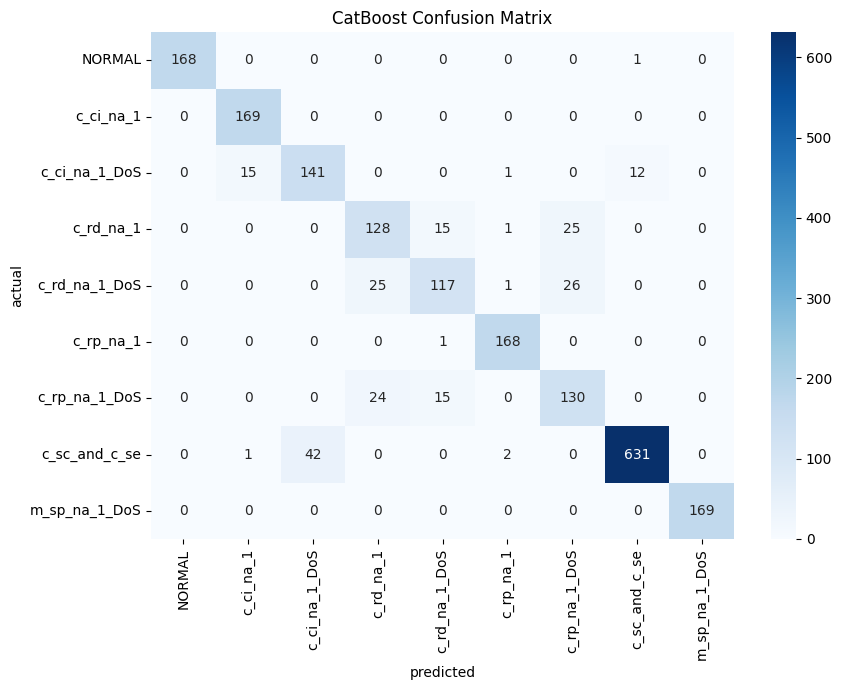

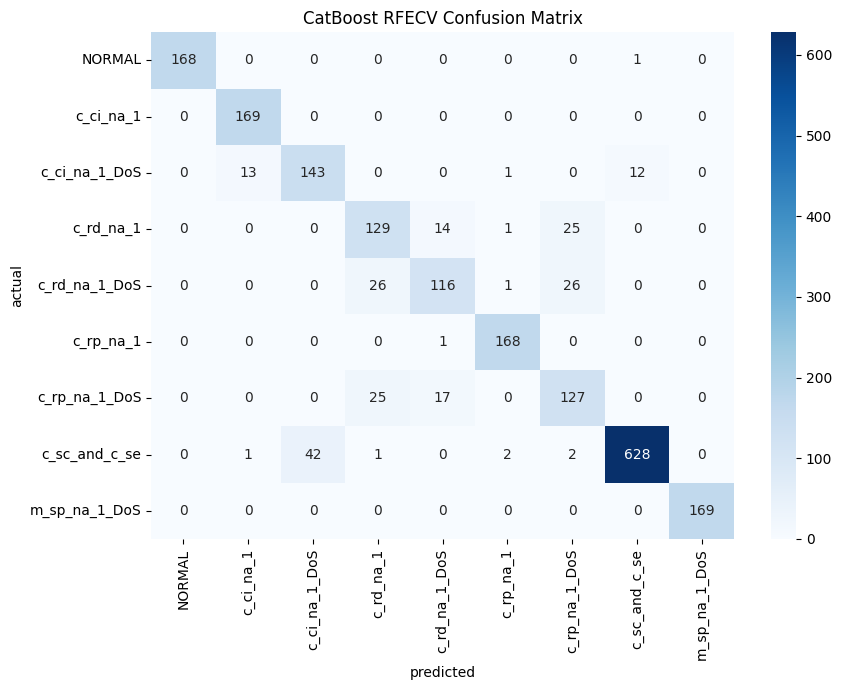

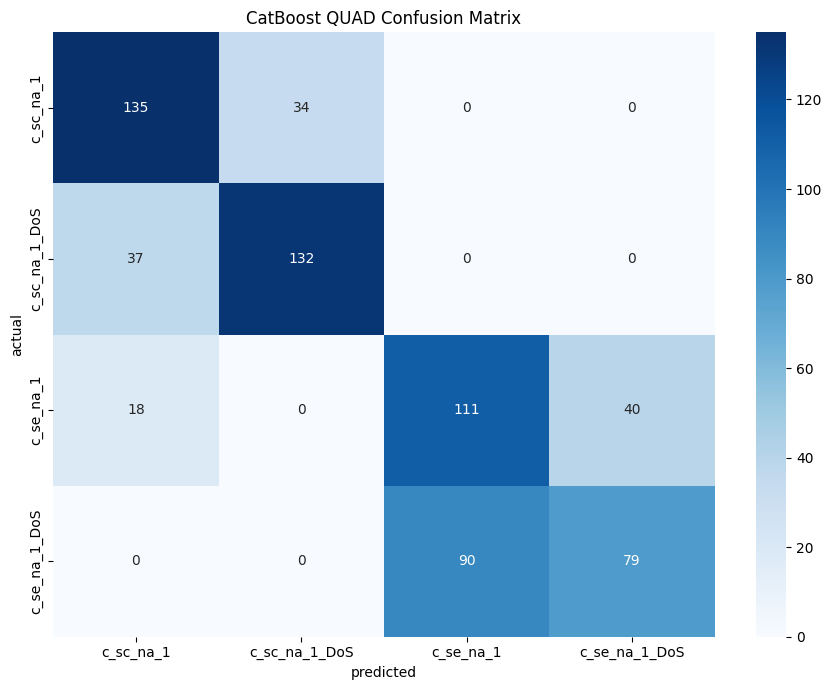

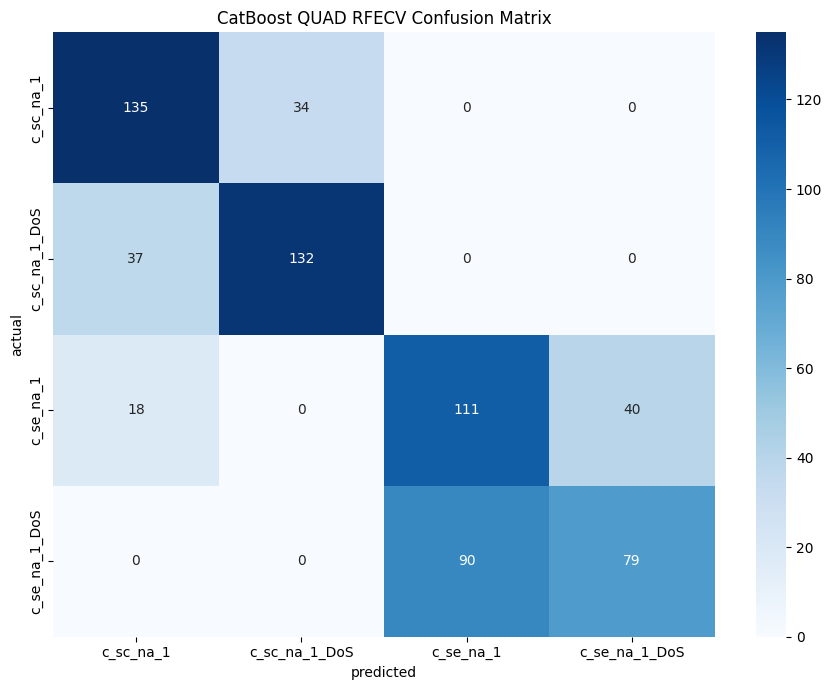

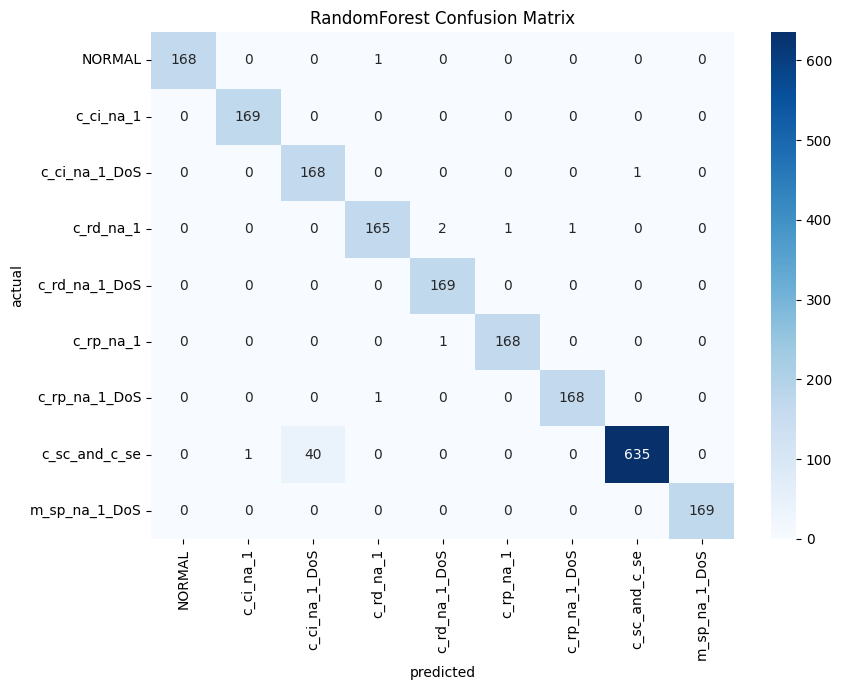

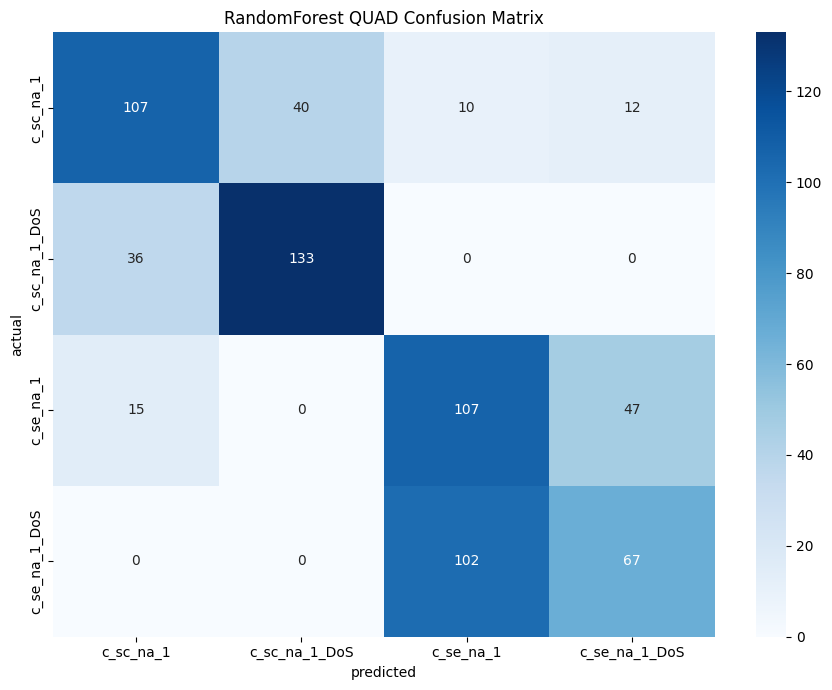

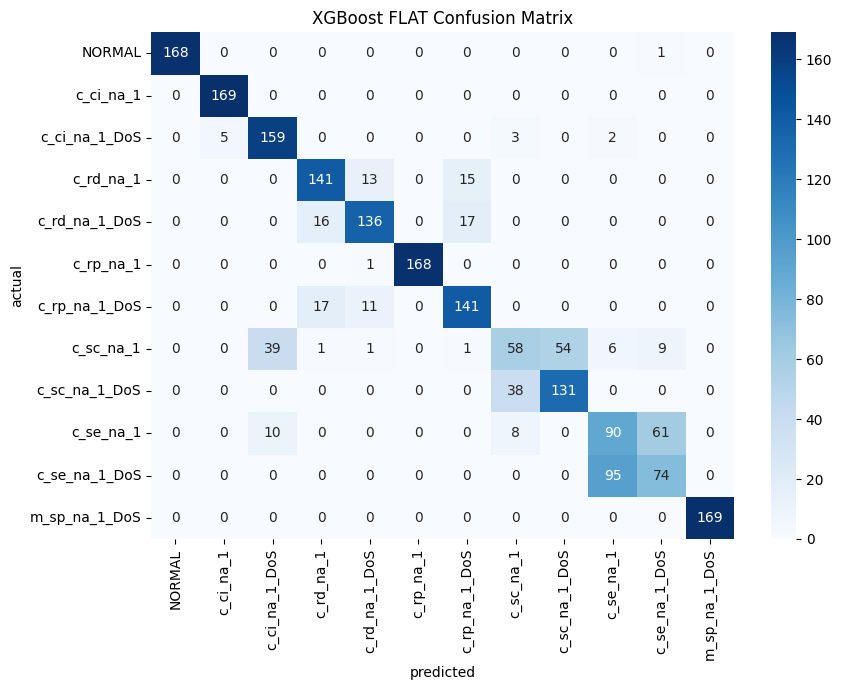

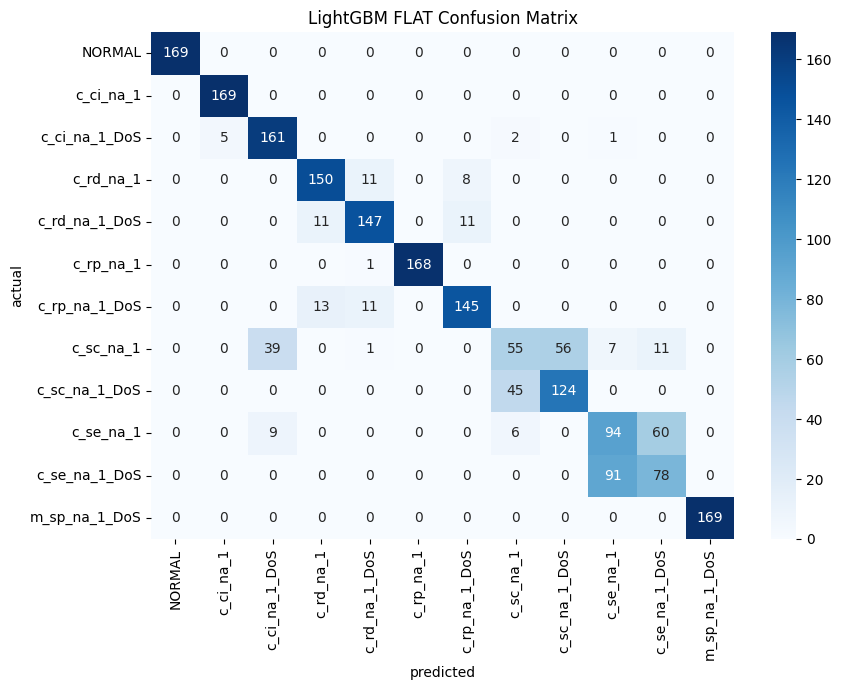

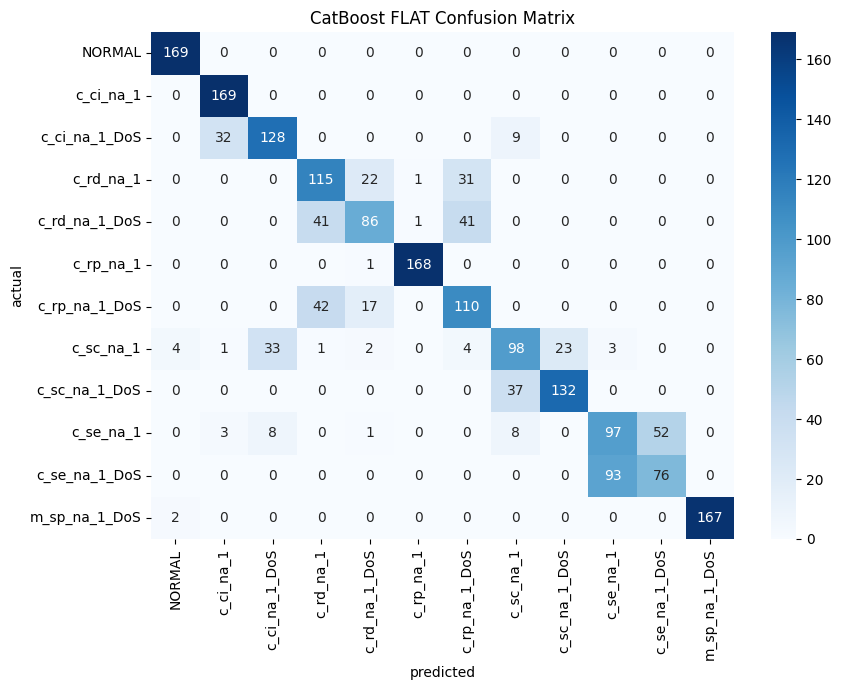

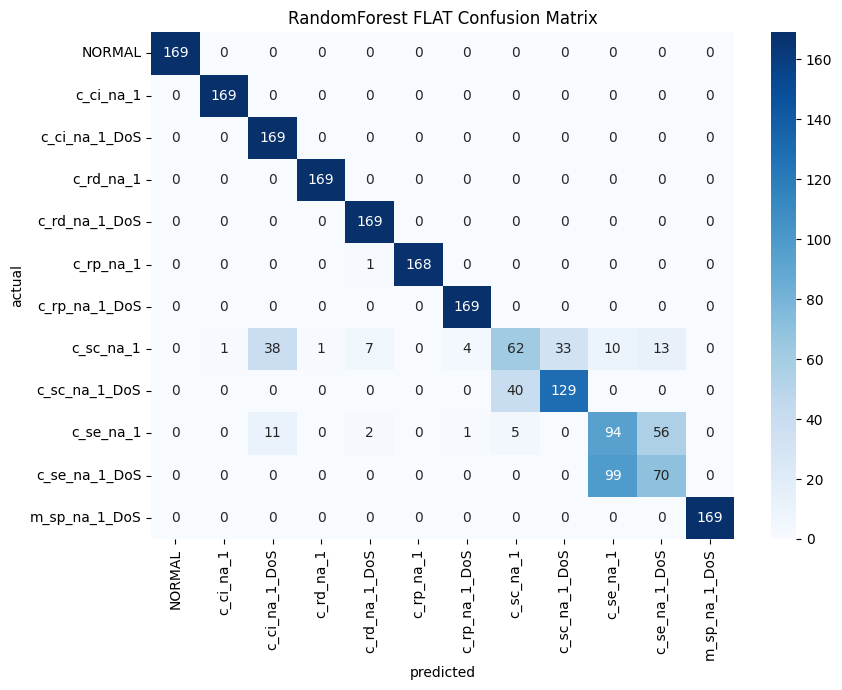

In [14]:
def confusion_matrixes(model, X, y, encoder, title):
    cm = confusion_matrix(y,model.predict(X))
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.xlabel('predicted')
    plt.ylabel('actual')
    plt.title(title + ' Confusion Matrix')
    plt.tight_layout()
    plt.show()

functions(confusion_matrixes)

### Confusion matrix
The 9 class models are doing pretty well especially the randomforestclassifier
the quad models in comparison to the flat models are better at predicting the quad classes 


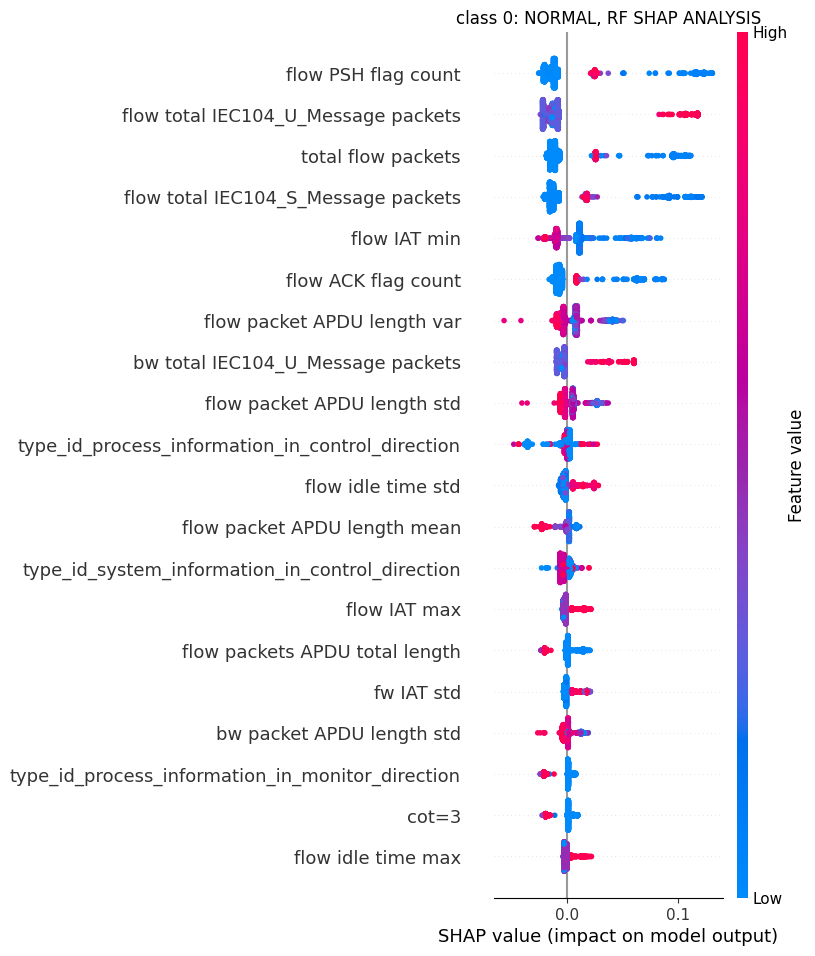

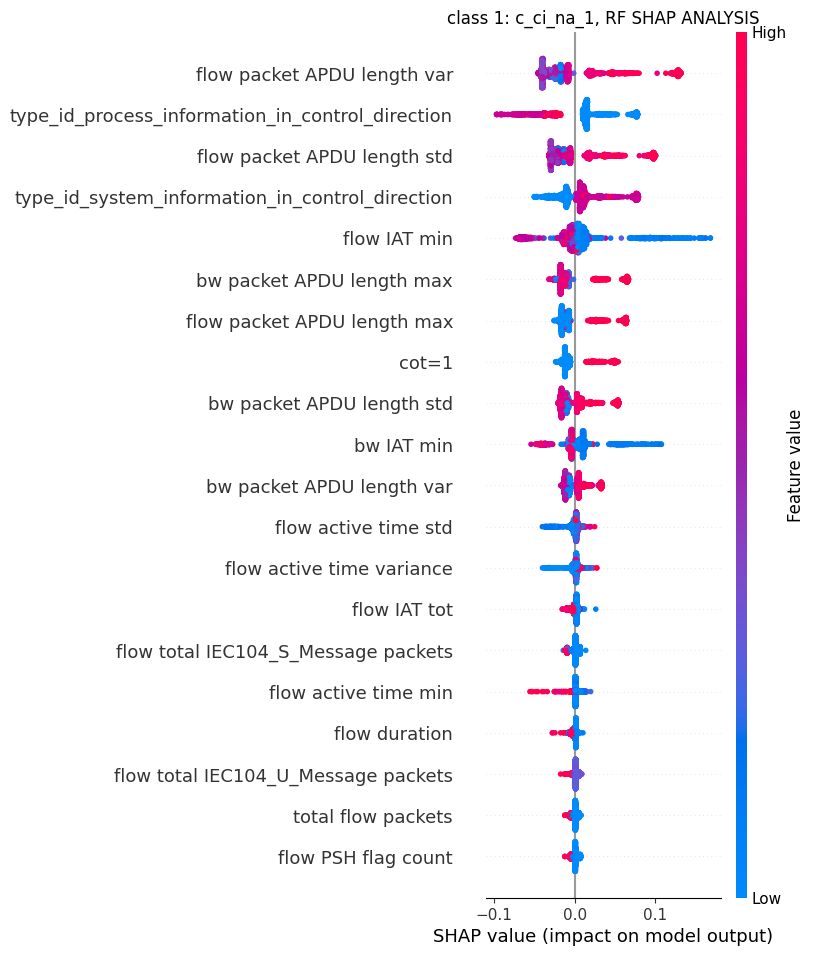

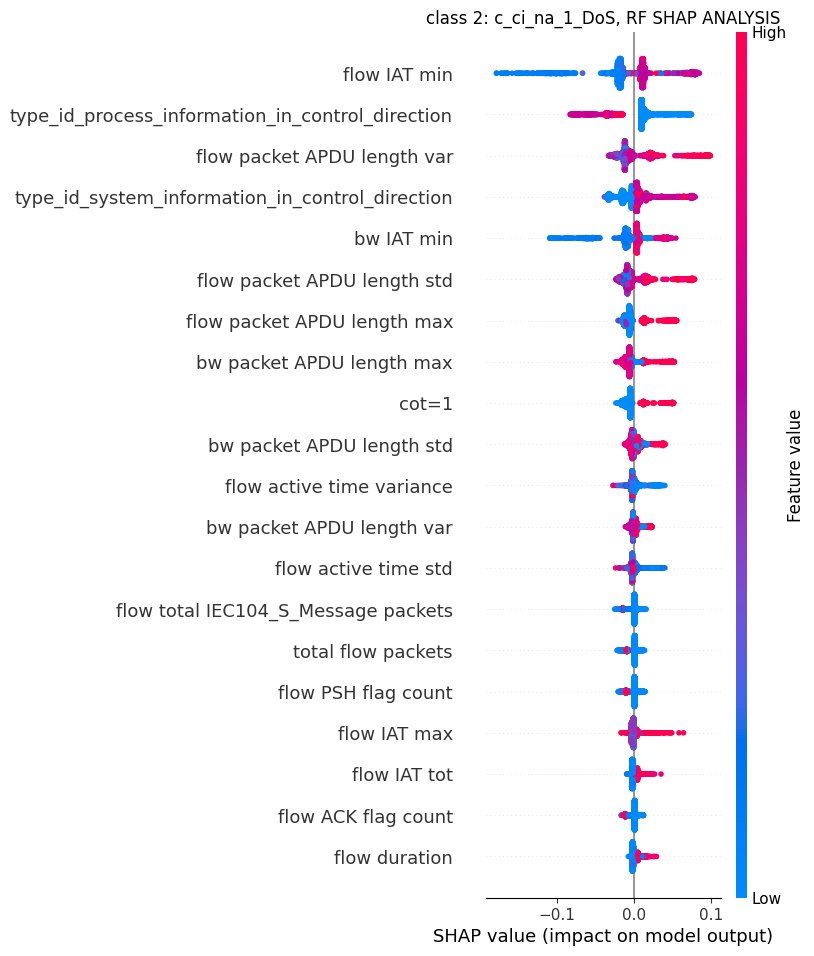

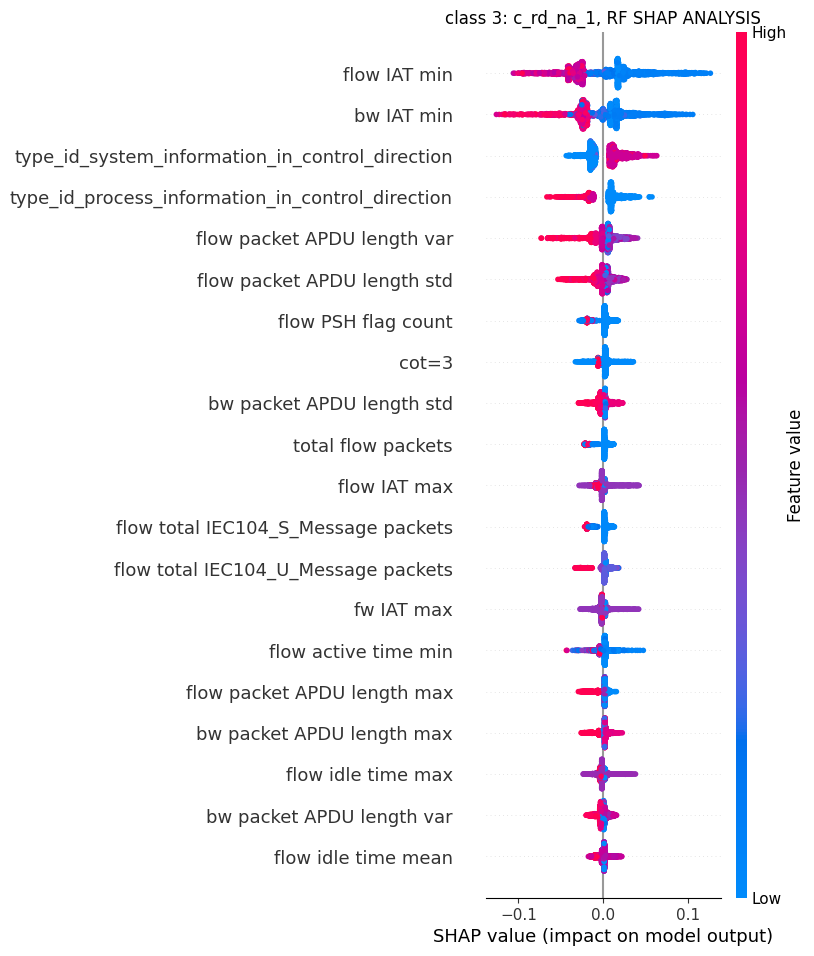

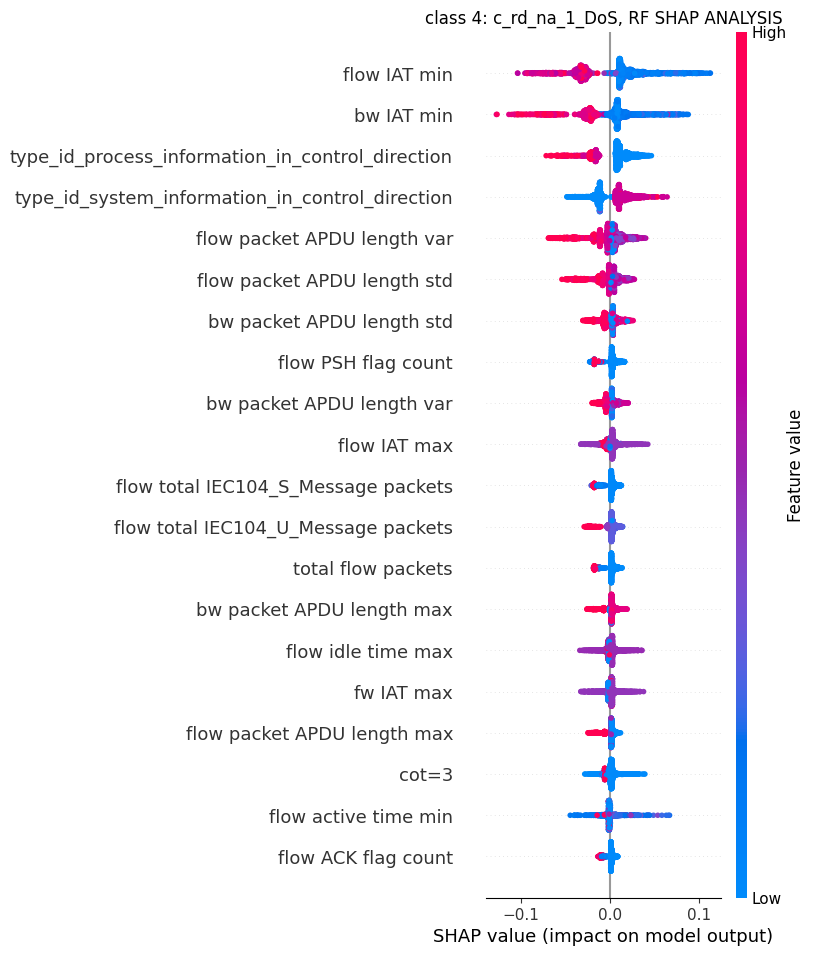

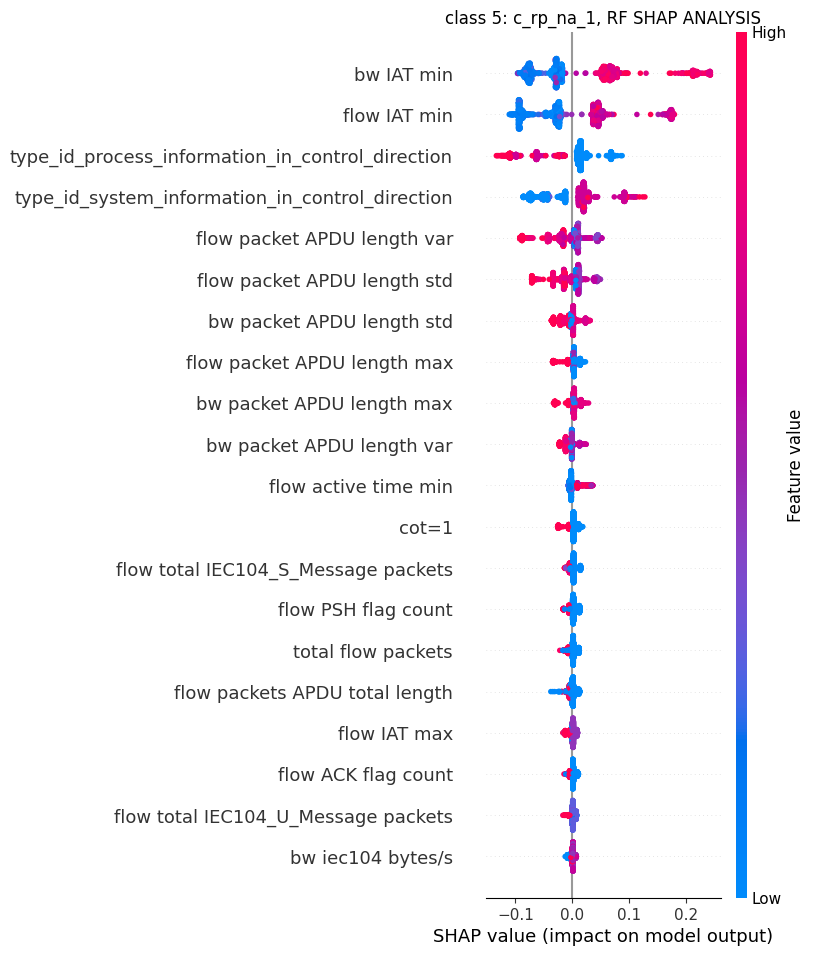

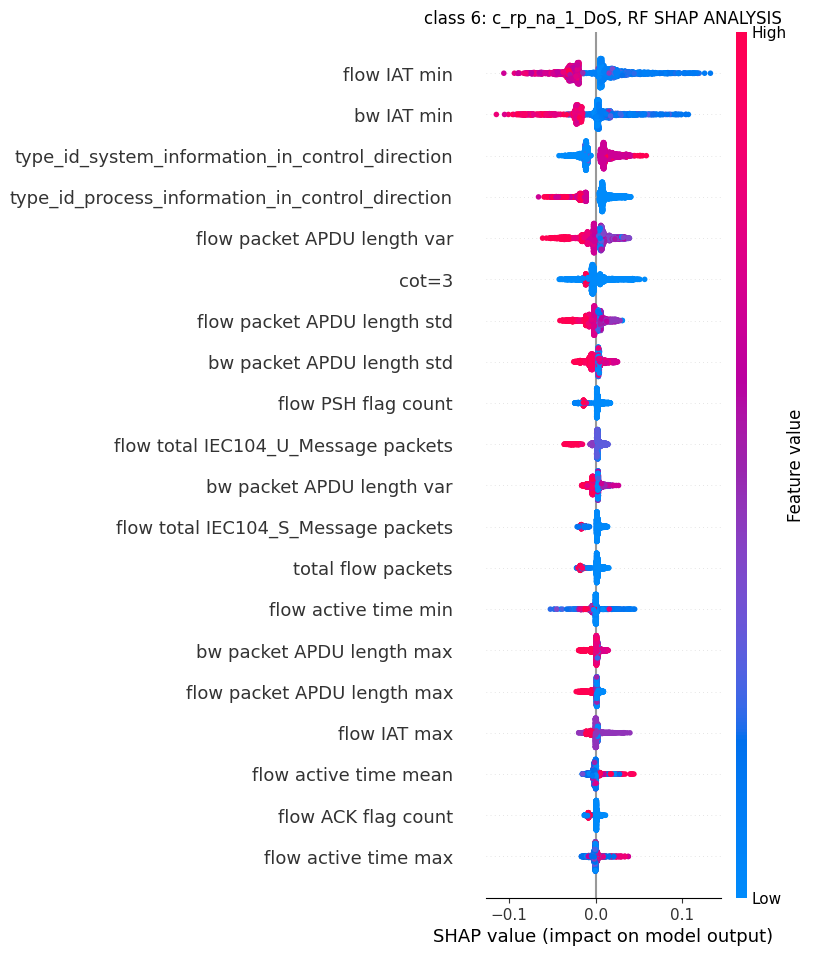

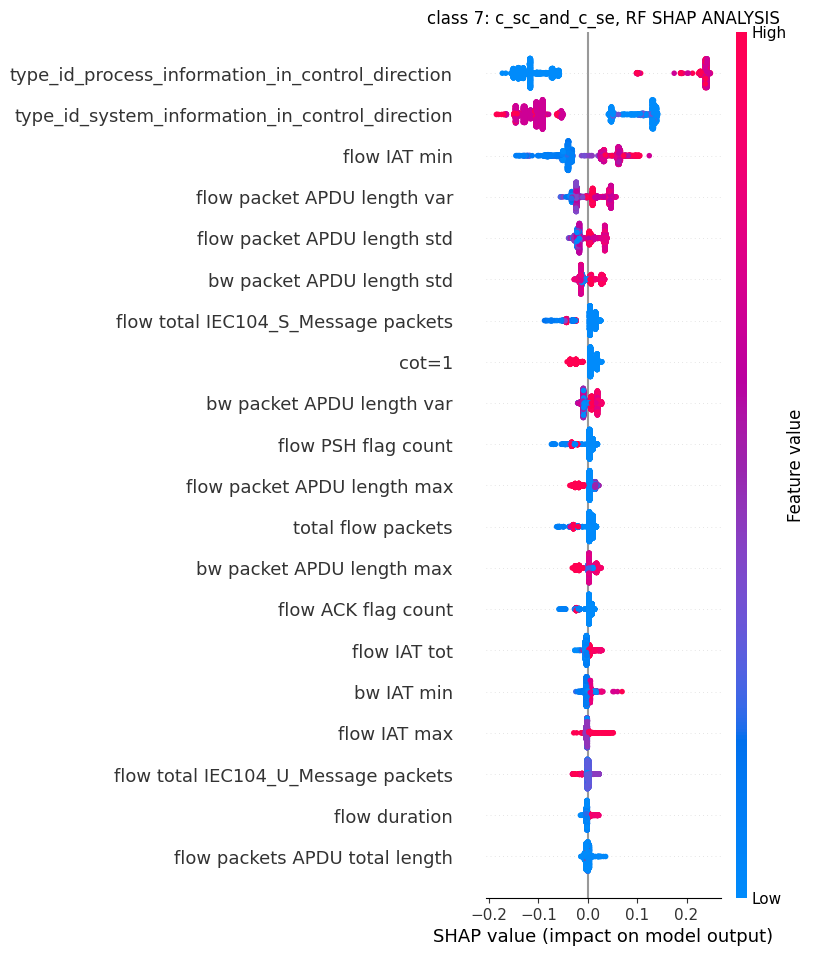

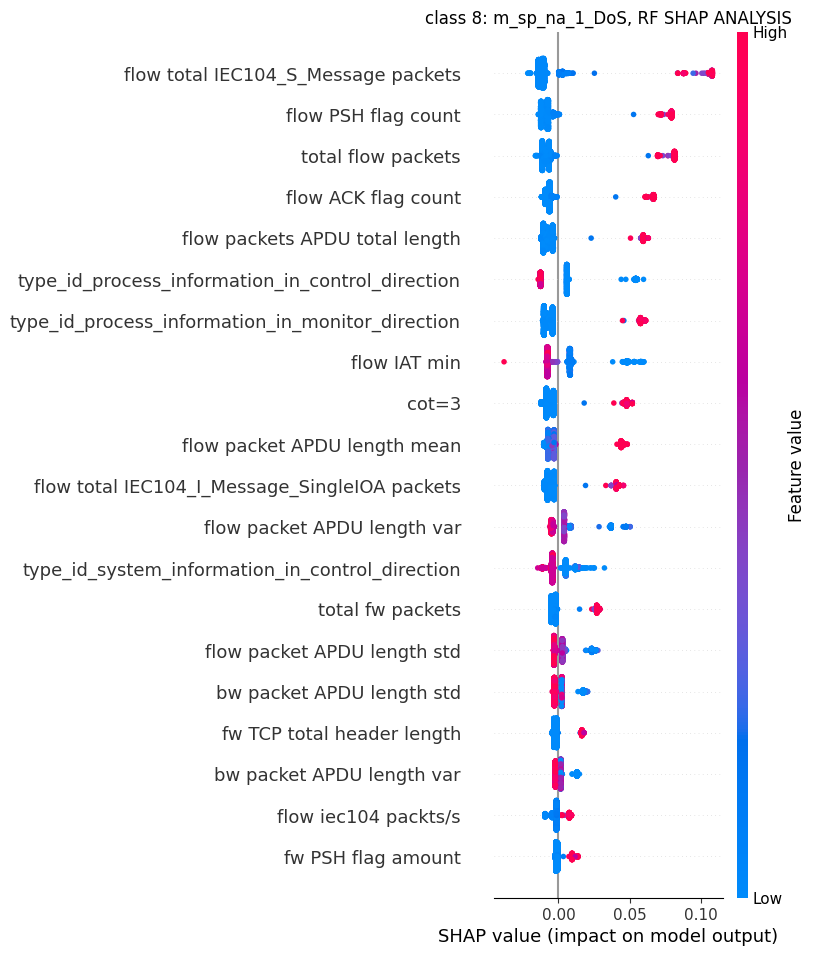

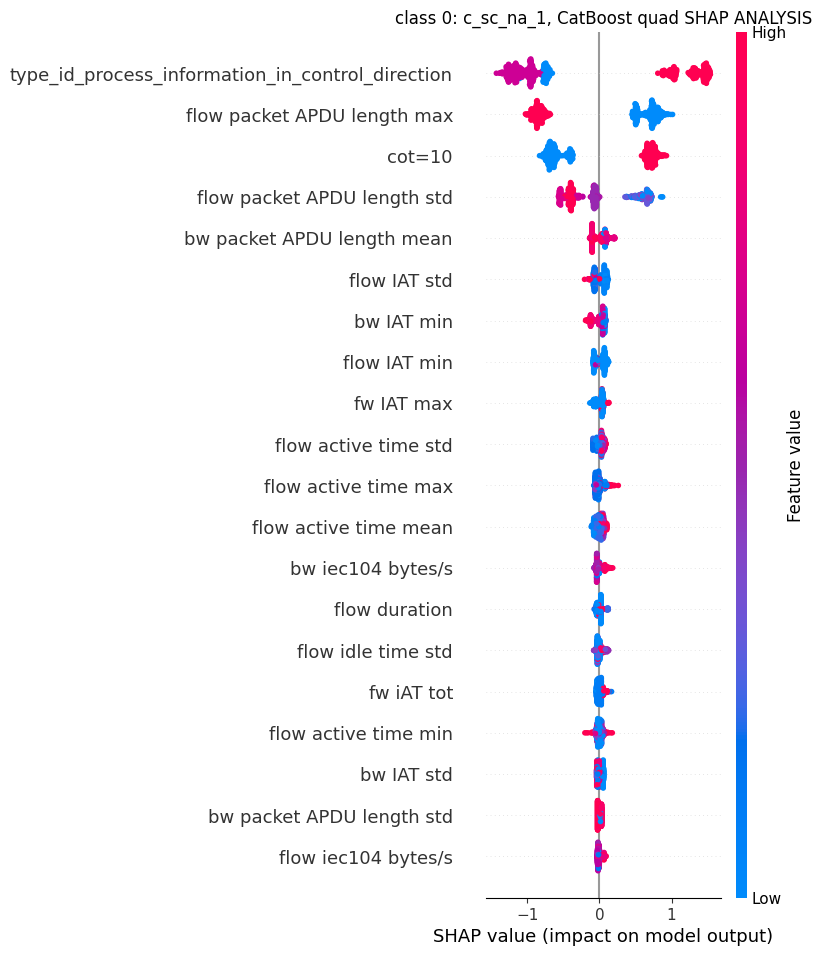

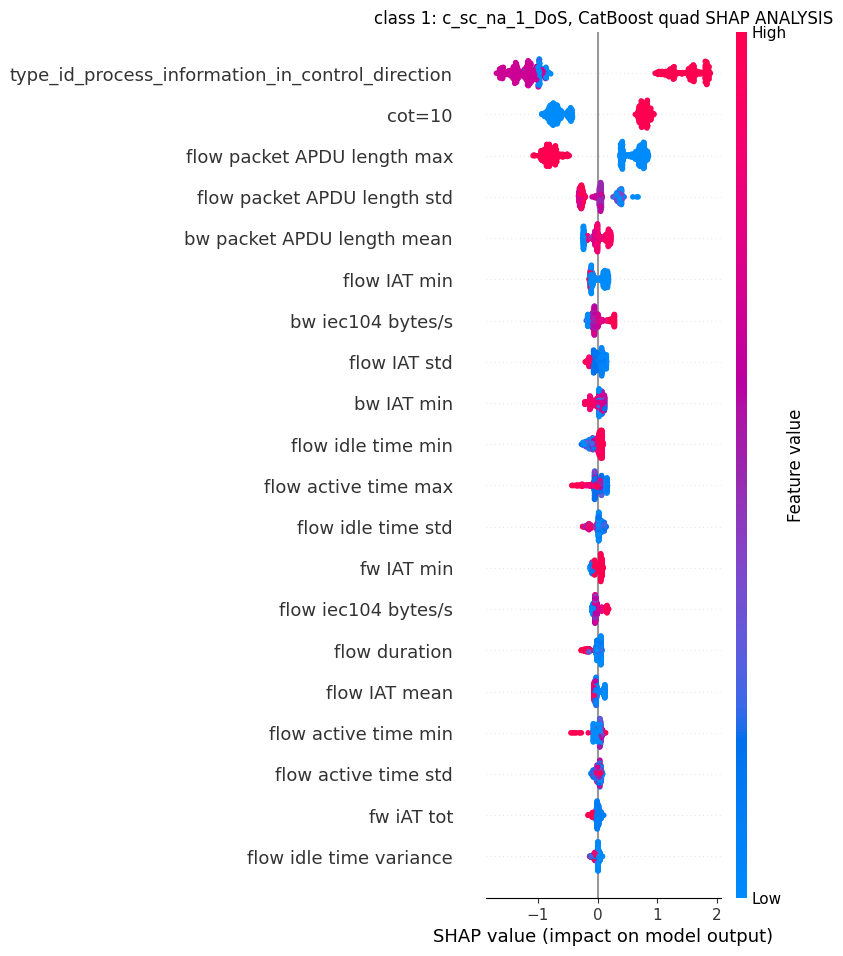

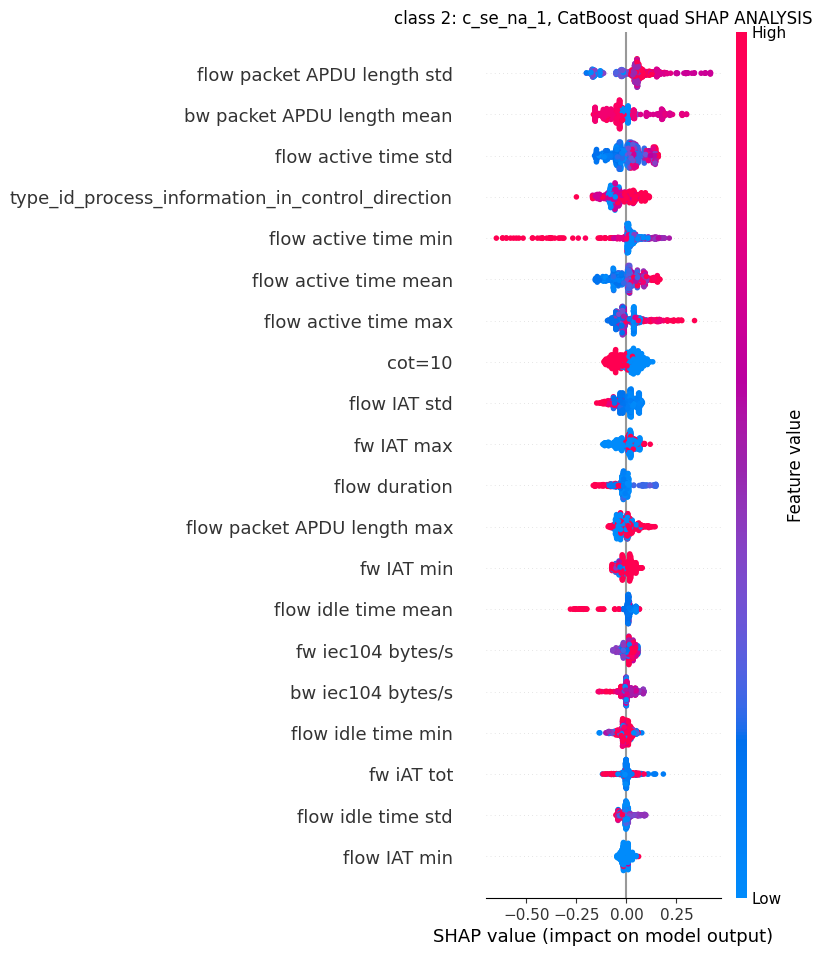

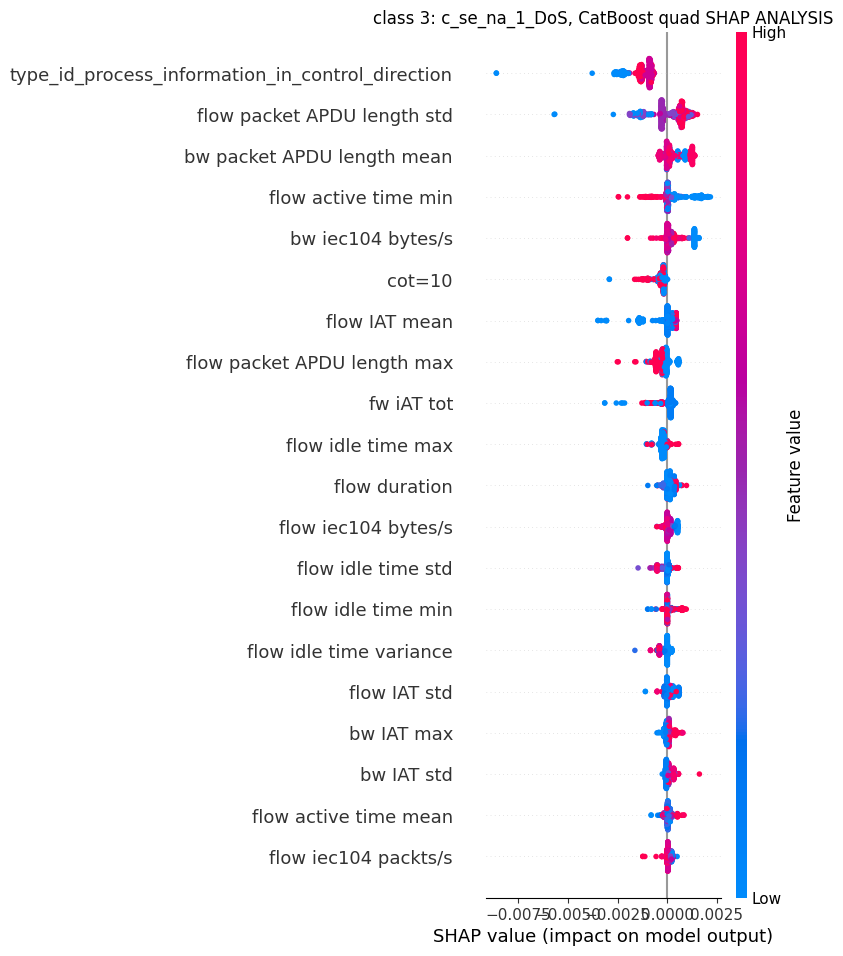

In [11]:
def Shap_(model,X_test,title):
    shap_explenation=shap.TreeExplainer(model)
    shap_values=shap_explenation.shap_values(X_test)
    shap_classes={c:shap_values[:,:,c] for c in range(class_range)}
    for i in range(class_range):
        shap.summary_plot(shap_classes[i],X_test,show=False)
        plt.title(f'class {i}: {le.classes_[i]}, {title}')
        plt.show()

def Shap_quad(model,X_test,title):
    shap_explenation=shap.TreeExplainer(model)
    shap_values=shap_explenation.shap_values(X_test)
    shap_classes={c:shap_values[:,:,c] for c in range(4)}
    for i in range(4):
        shap.summary_plot(shap_classes[i],X_test,show=False)
        plt.title(f'class {i}: {le_quad.classes_[i]}, {title}')
        plt.show()
Shap_(rf_model,X_test,"RF SHAP ANALYSIS")

Shap_quad(Catboost_model_quad,X_test_quad,"CatBoost quad SHAP ANALYSIS")

# SHAP — most influential feature per class

### normal — flow PSH flag count. This makes sense, because its low values help the prediction toward the normal class. This reflects the nature of IEC-104 normal traffic: in comparison, the DoS attacks skyrocket this number and the injections add to it from the baseline. Also, flow total IEC104_U_Message packets has the 2nd highest SHAP value, which makes sense since this feature is built from normal traffic.

### c_ci_na_1 — flow packet APDU length var. That's because c_ci_na_1 is a command that asks the RTU to return many metric values, so the response contains many information objects with big length. This explains the good separation between this class and its DoS counterpart.

### For c_rd_na_1 and c_rd_na_1_DoS, their top SHAP values are the same, so these features help the model recognize that they correspond either to the injection version or to the DoS version. The secondary features help recognize which one is which.

### c_rp_na_1 and c_rp_na_1_DoS have 4 top SHAP values with exactly the opposite direction, which means that the model is using these features to distinguish the normal version from the DoS version.

### For c_sc_and_c_se, what helps is type_id_process_information_in_control_direction and type_id_system_information_in_control_direction, which makes sense since they are bucketed together: c_sc_na_1 is type_id 45 and c_se_na_1 is type_id 48.

### m_sp_na_1_DoS — flow total IEC104_S_Message packets gets many S packets, and the flooding of the network differentiates it from the other classes. Also, type_id_process_information_in_monitor_direction is shown only here, since this class is the only monitor-direction one in the dataset, with type_id 1.

### Quad family — the SHAP values for the 2 first classes are separated more clearly, with value impact ranging from -1 to 1 and -1 to 2, the top ones being type_id_process_information_in_control_direction and flow packet APDU length max. Meanwhile, c_se_na_1 has a range from -0.5 to 0.25 and the DoS version from -0.0075 to 0.0025, which explains the confusion matrix and the f1-macro scores on these classes.

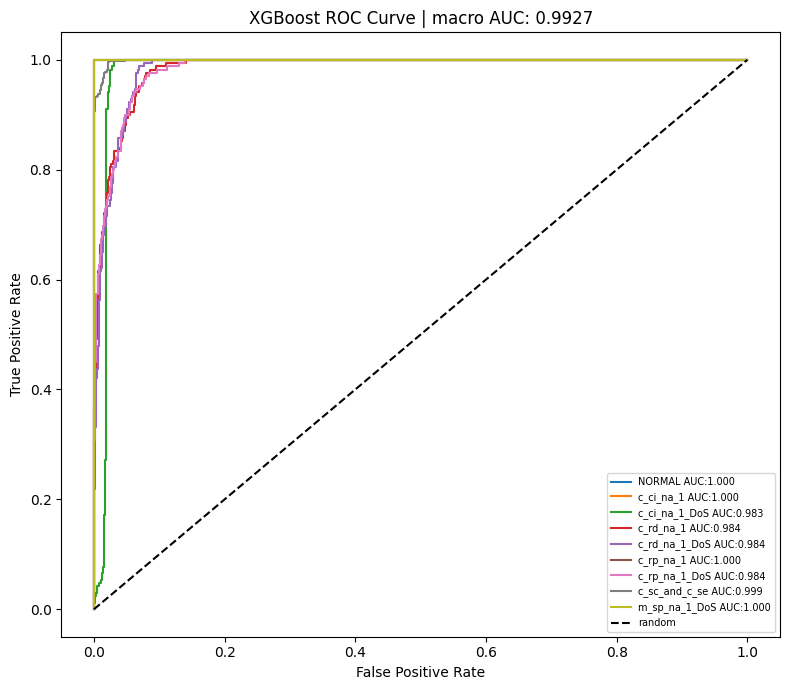

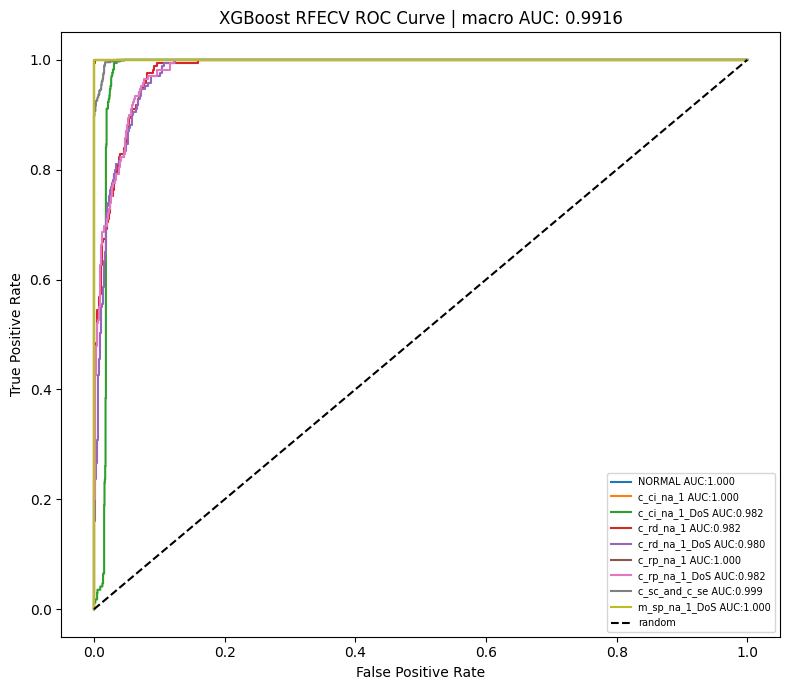

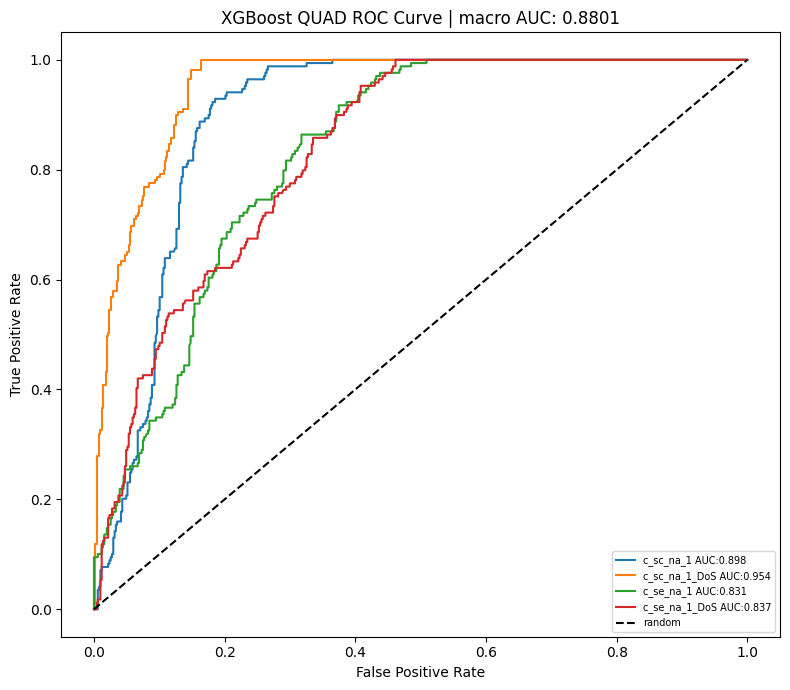

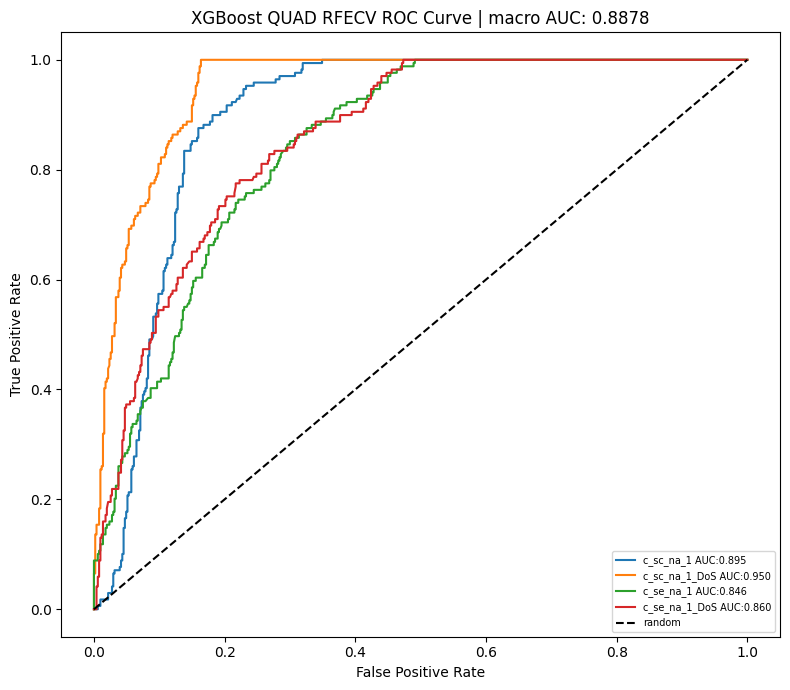

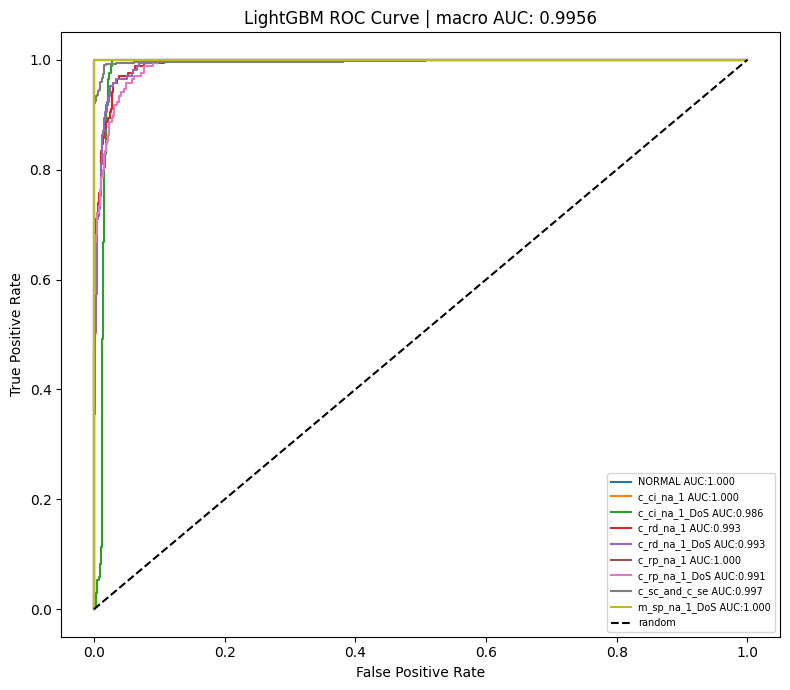

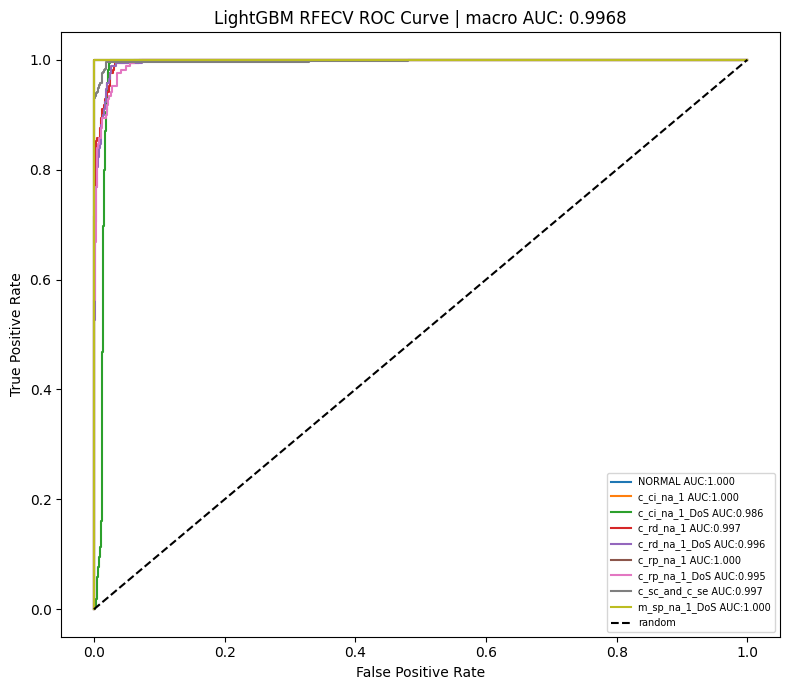

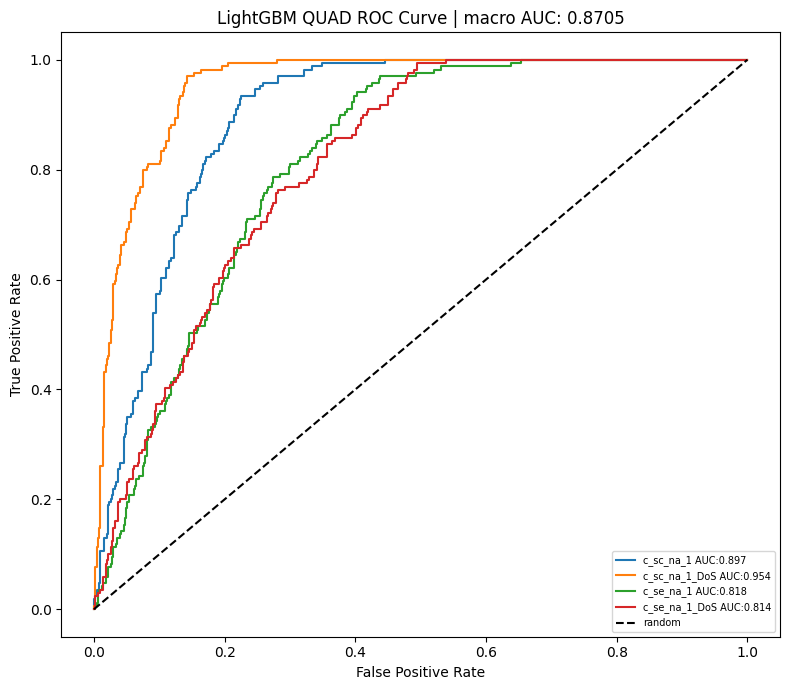

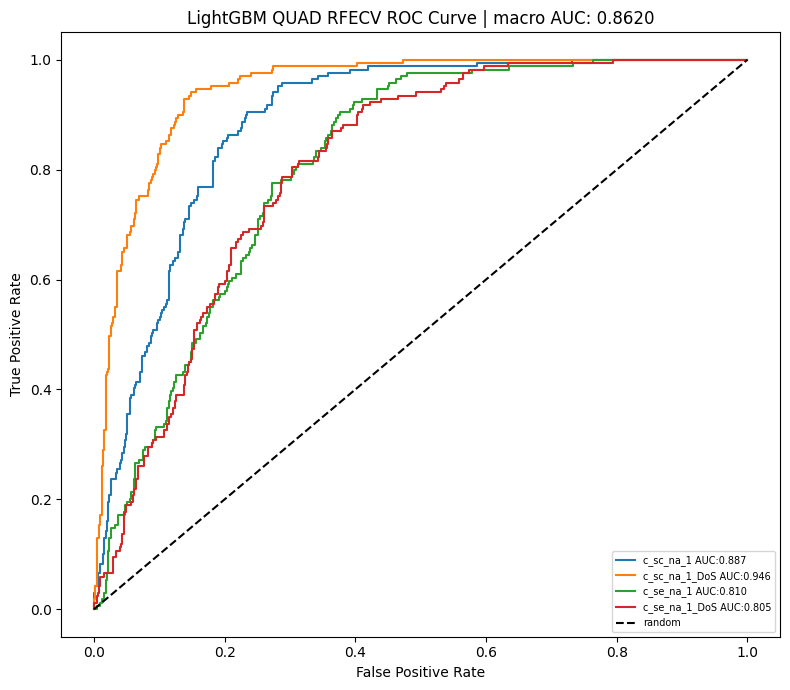

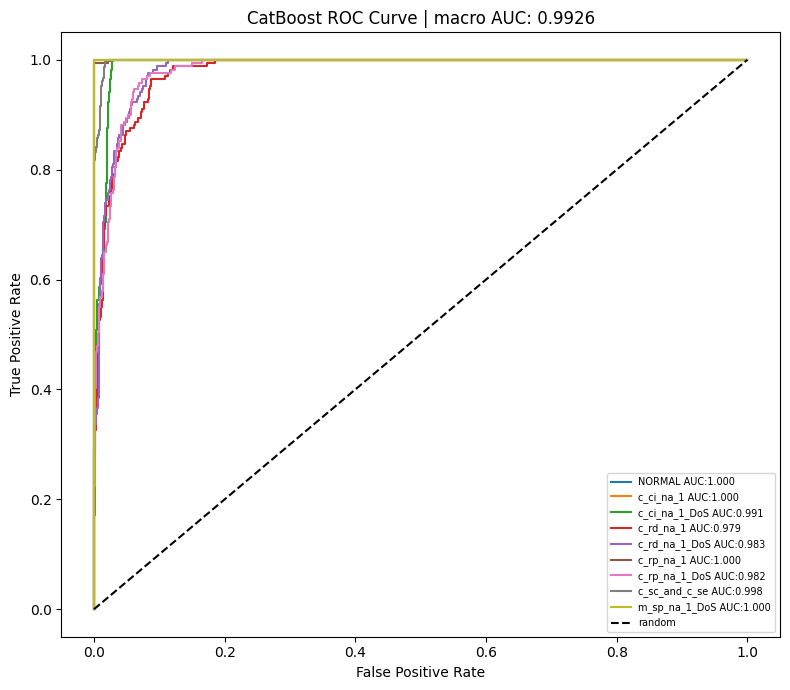

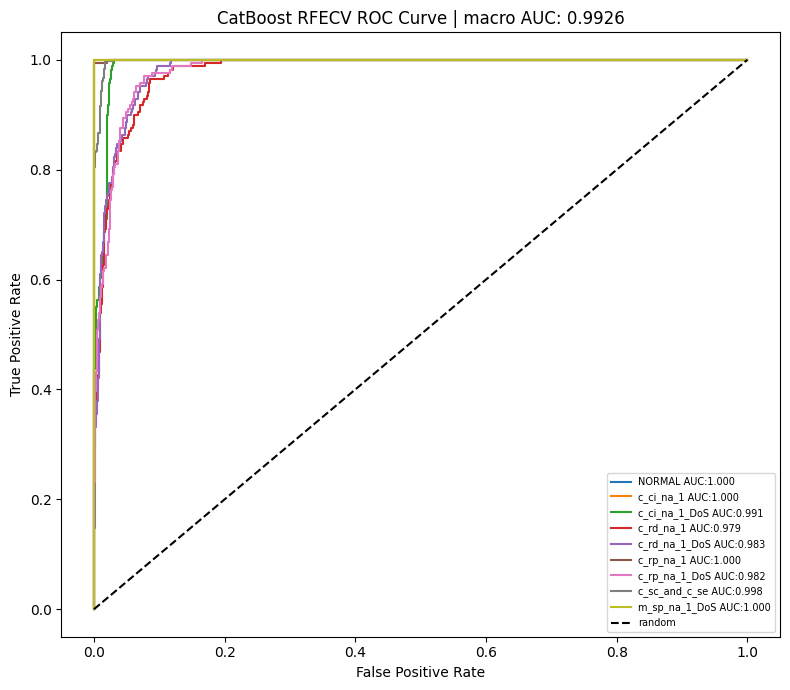

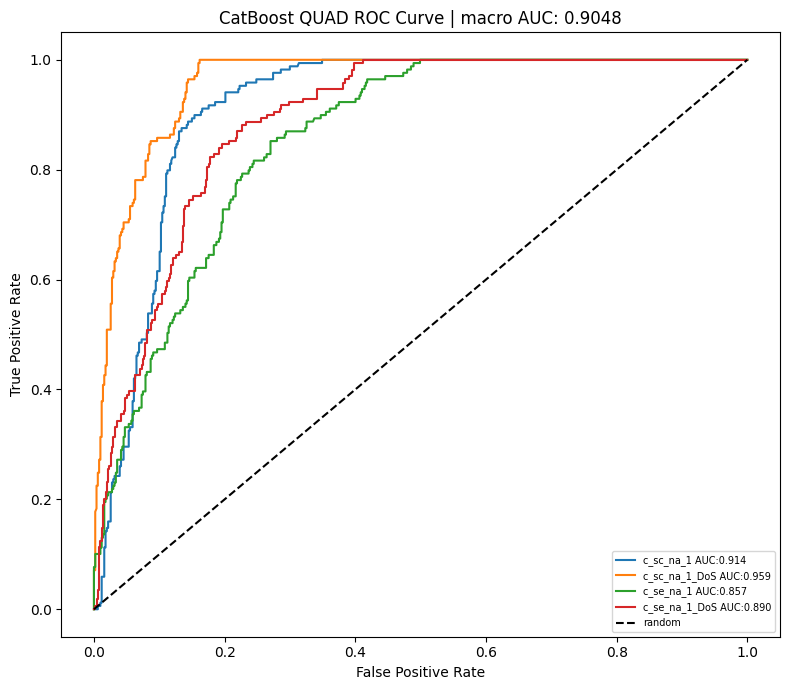

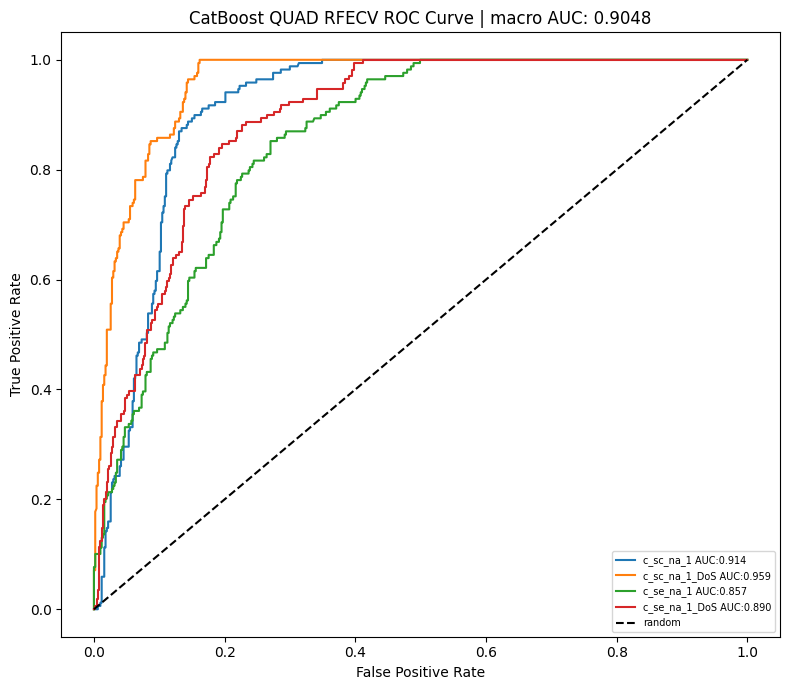

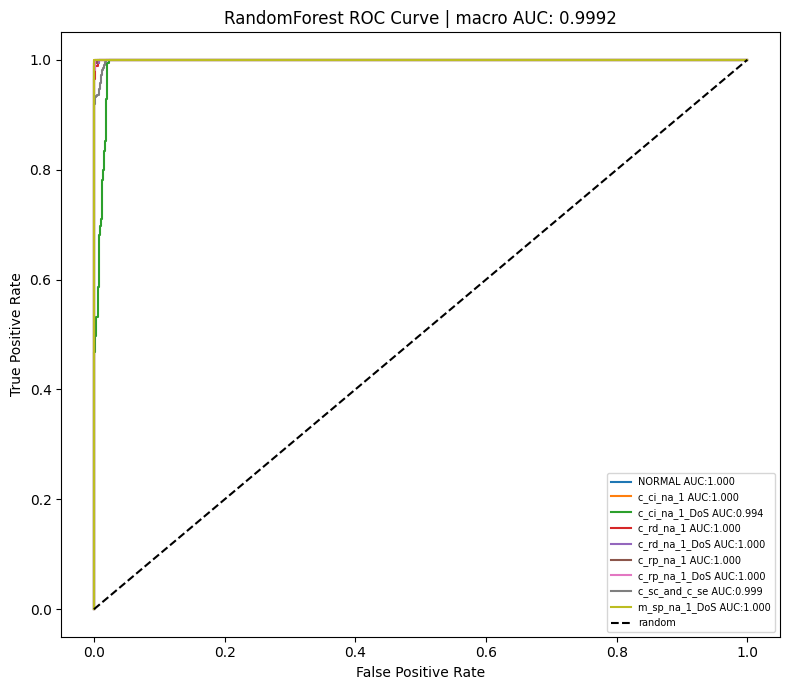

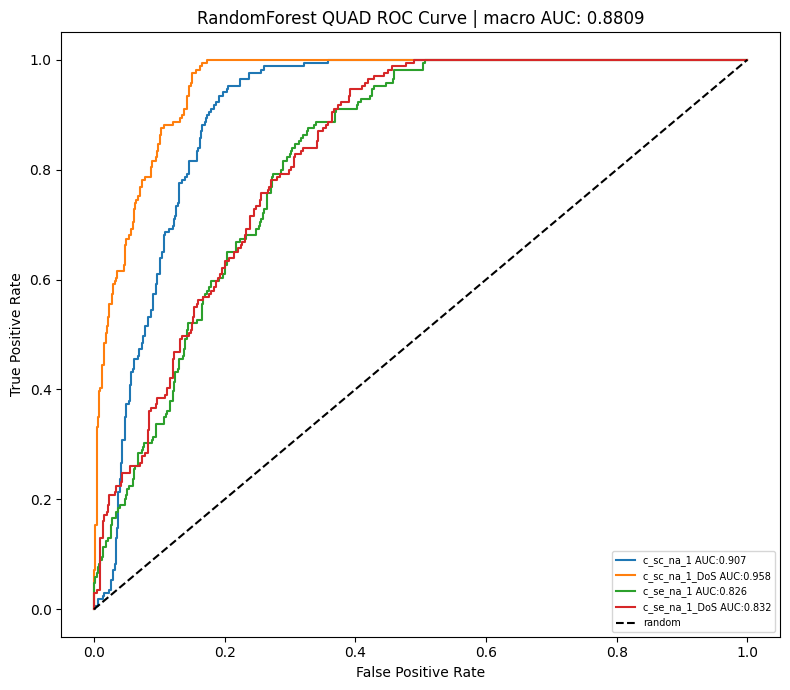

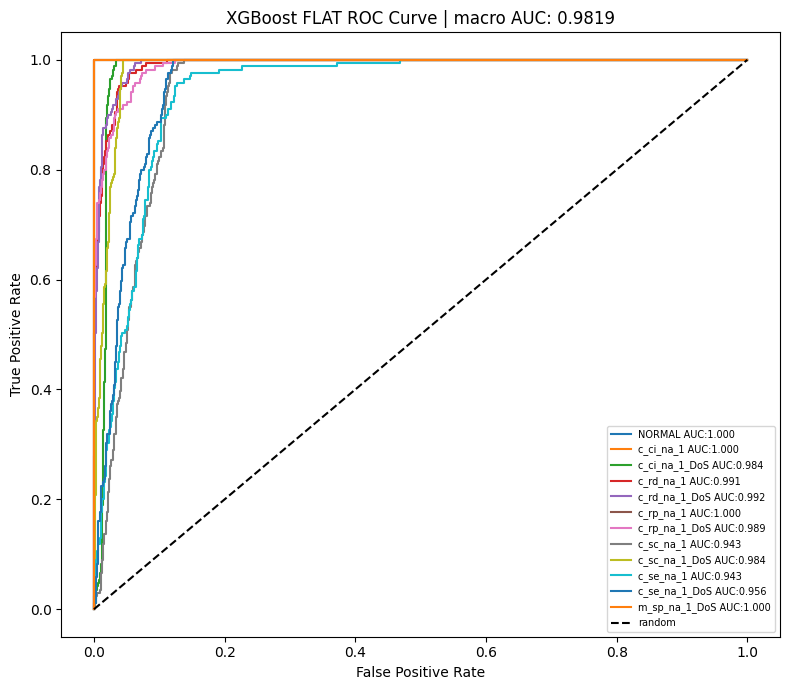

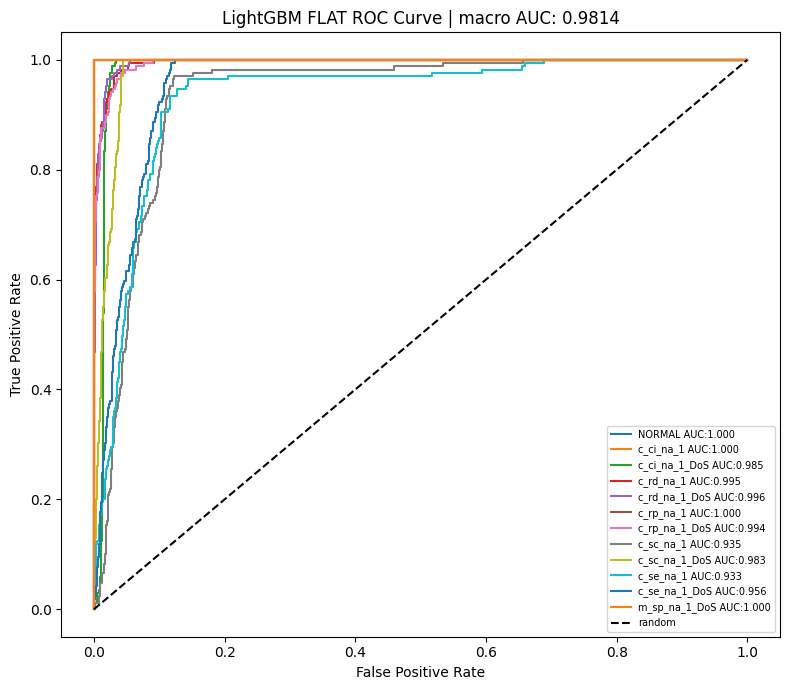

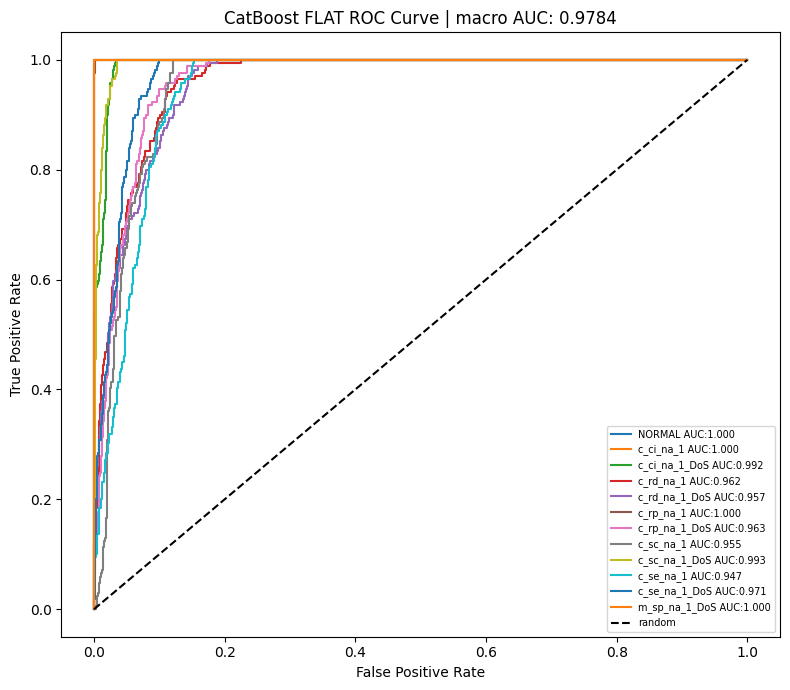

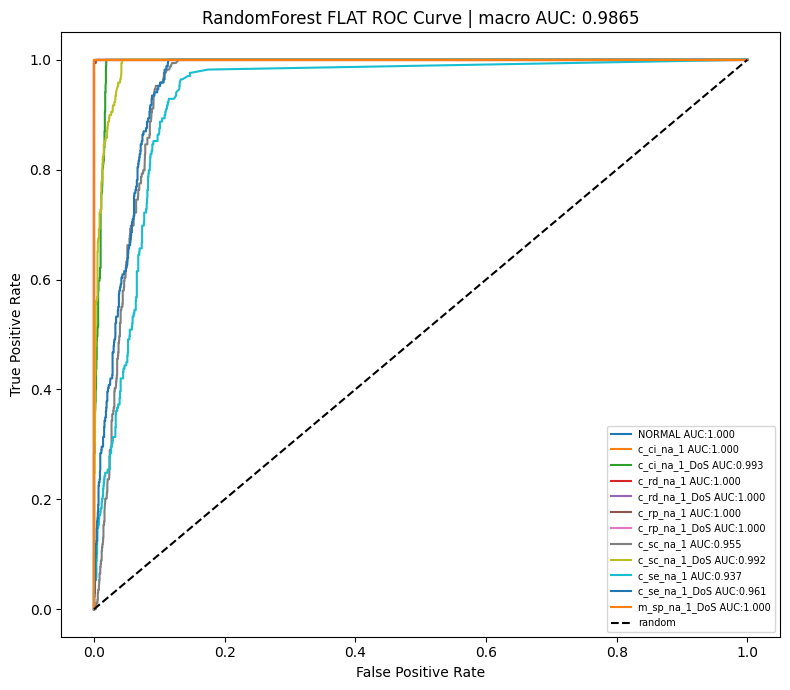

In [12]:
def roc_curve_auc(model, X, y_true, enc, title):
    n = len(enc.classes_)
    y_bin = label_binarize(y_true, classes=range(n))
    proba = model.predict_proba(X)

    macro_auc = roc_auc_score(y_true, proba, multi_class='ovr', average='macro')

    plt.figure(figsize=(8, 7))
    for i in range(n):
        fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
        plt.plot(fpr, tpr, label=f'{enc.classes_[i]} AUC:{auc(fpr, tpr):.3f}')
    plt.plot([0, 1], [0, 1], 'k--', label='random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize=7)
    plt.title(f'{title} ROC Curve | macro AUC: {macro_auc:.4f}')
    plt.tight_layout()
    plt.show()

functions(roc_curve_auc)

the best roc auc score goes to the random forest for the 9 classes with macro auc
 0.9992
and for the quad model it goes to the catboost_quad with macro auc 0.9048 

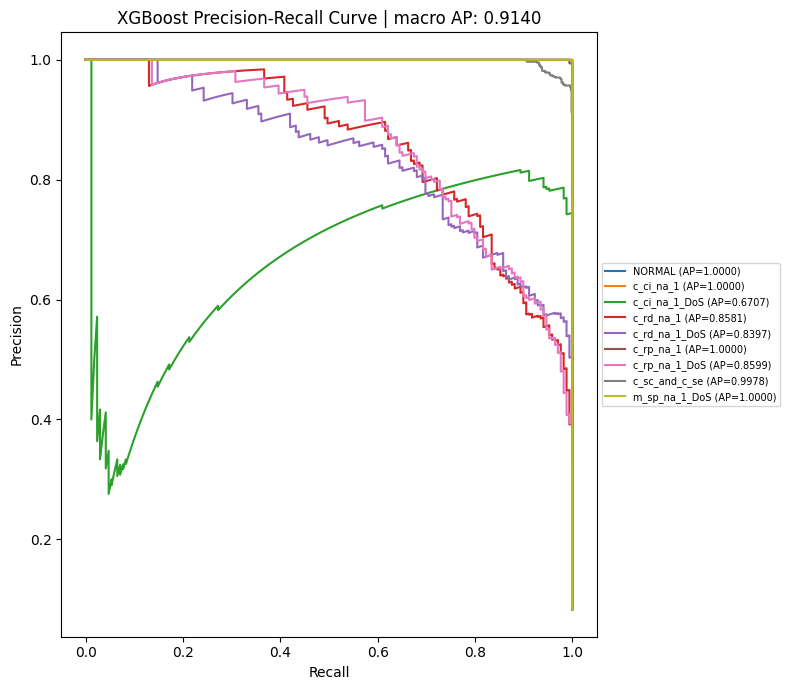

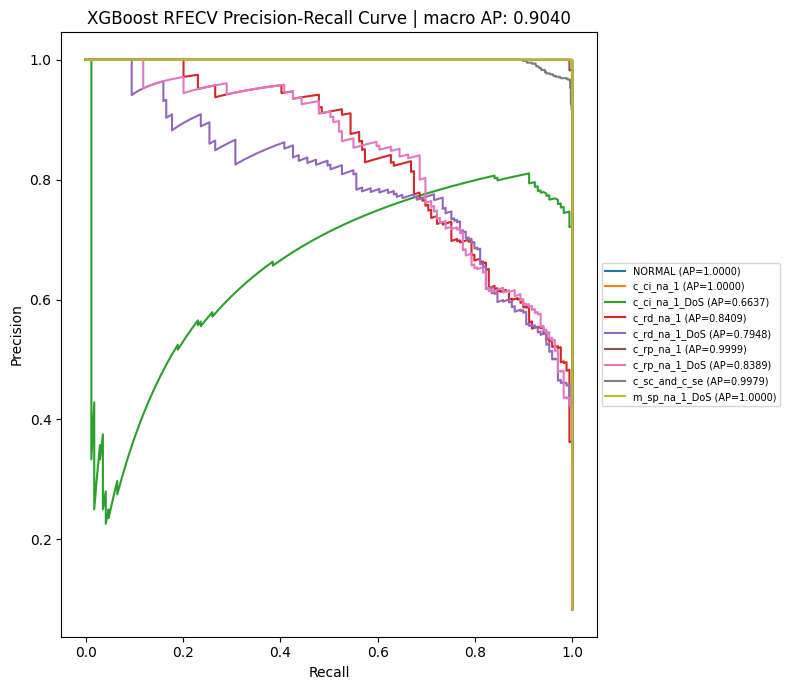

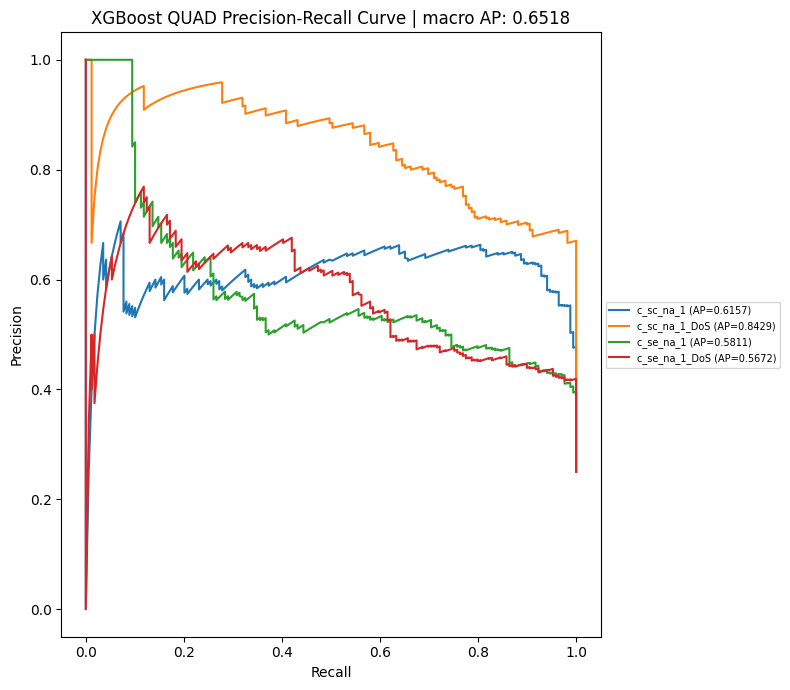

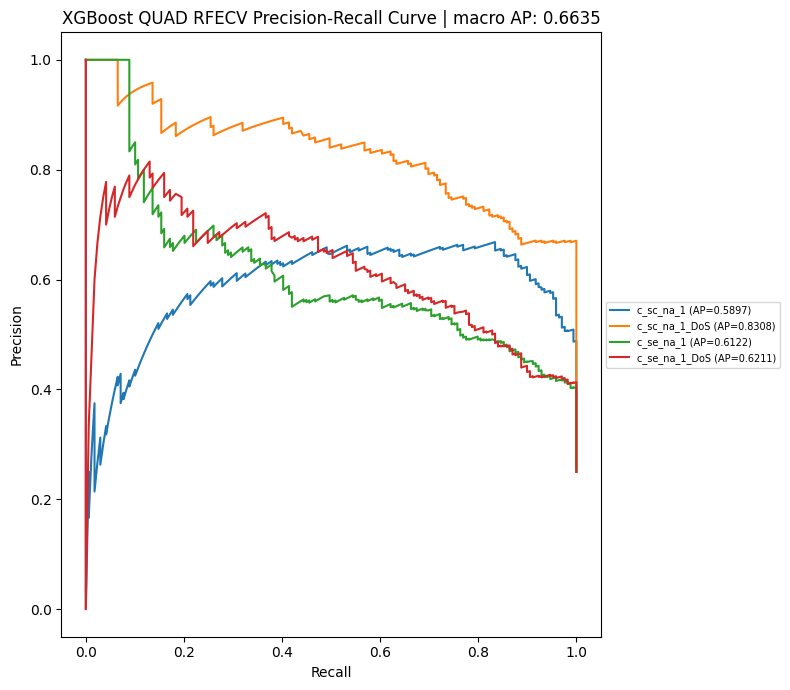

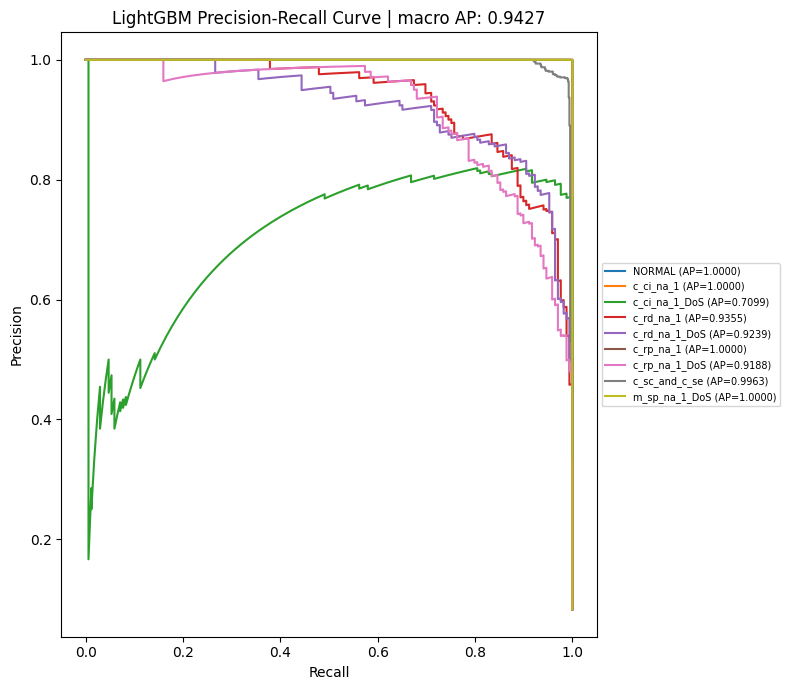

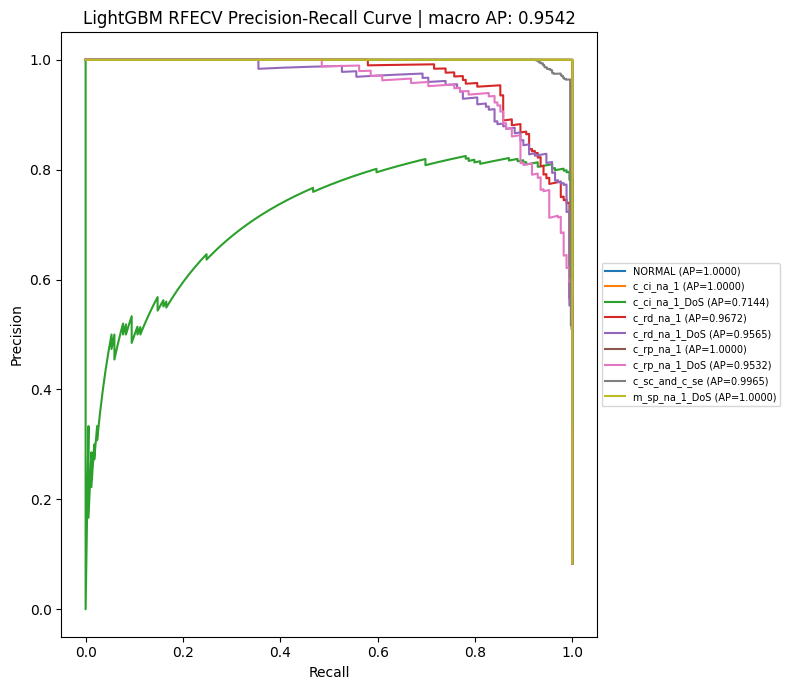

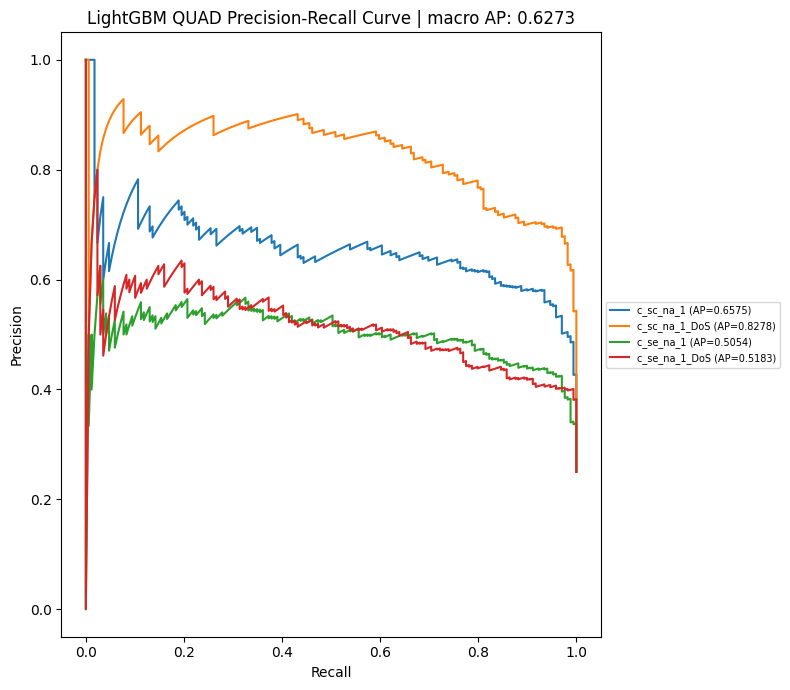

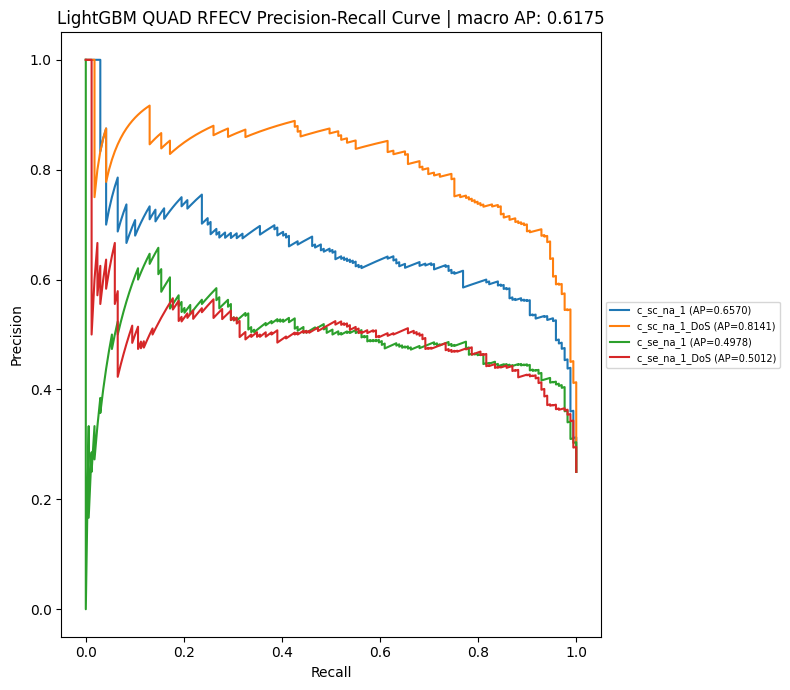

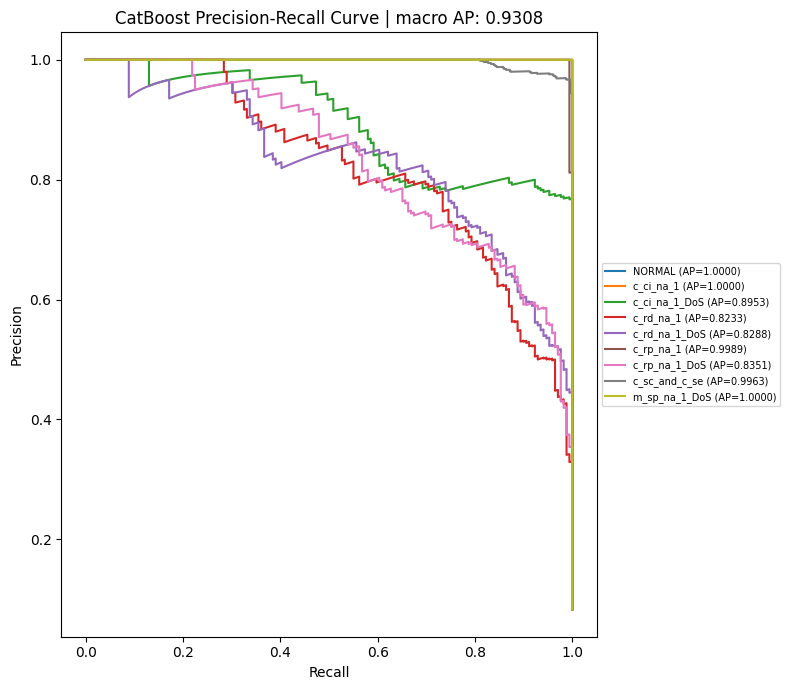

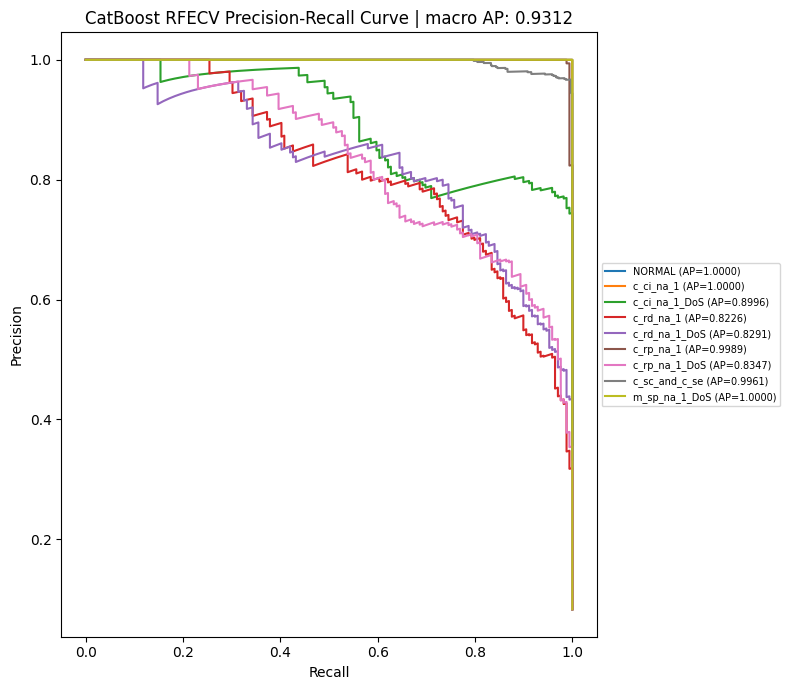

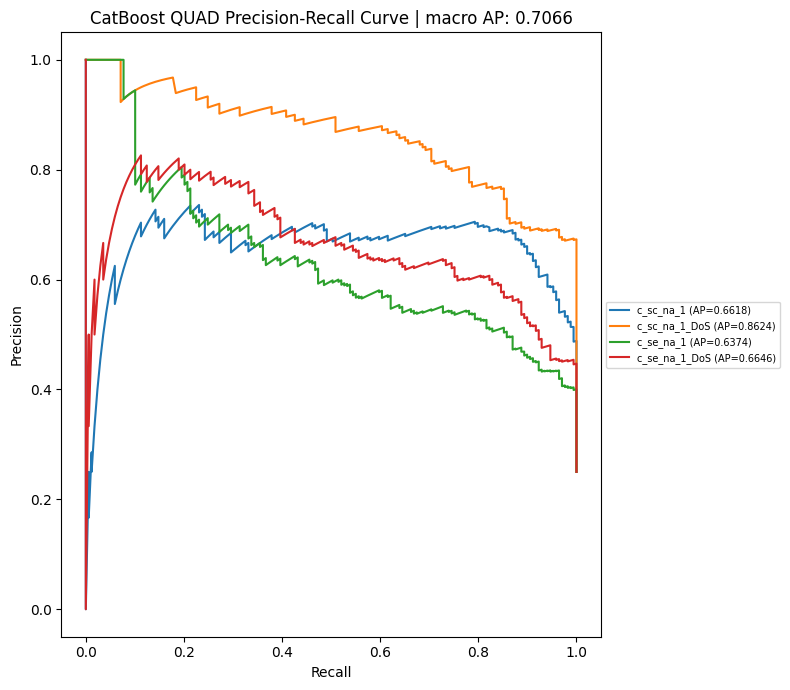

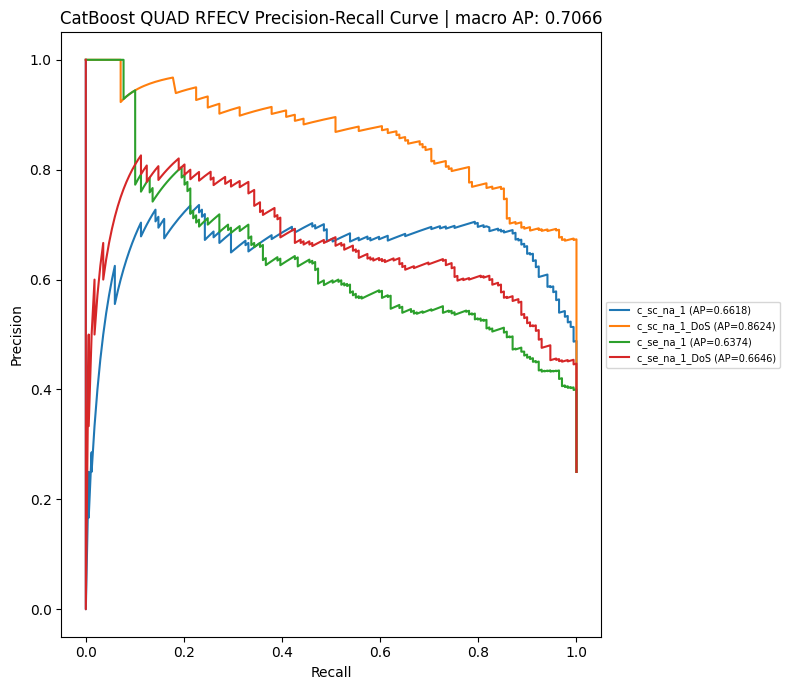

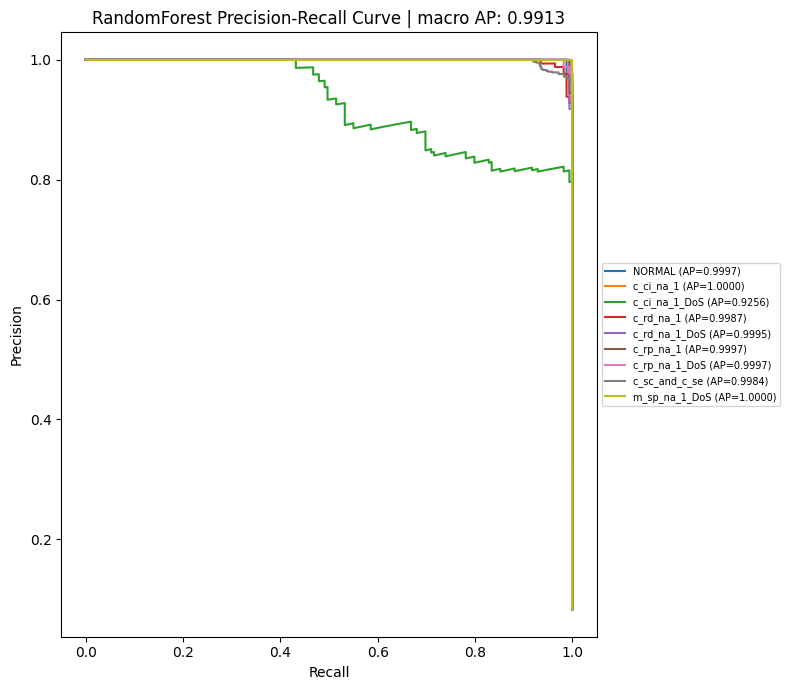

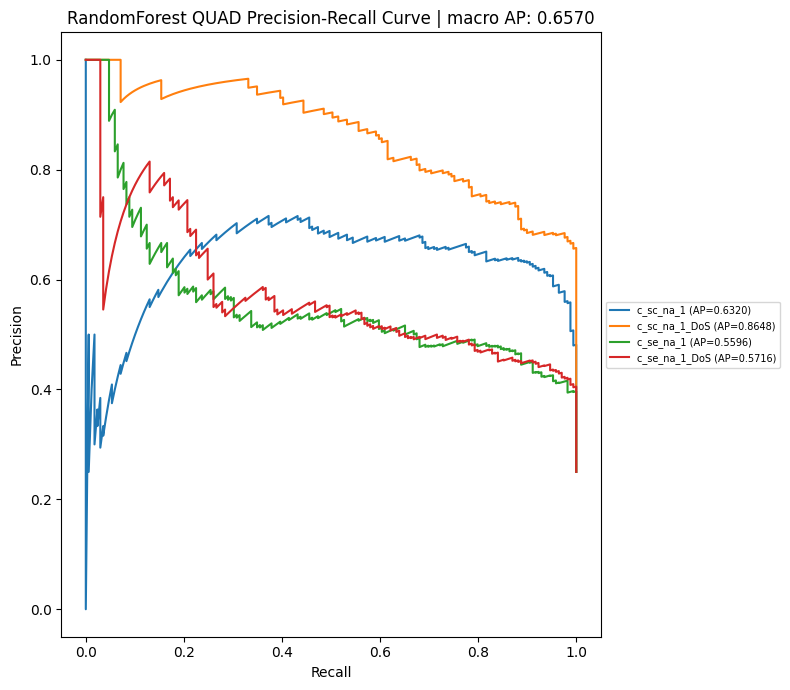

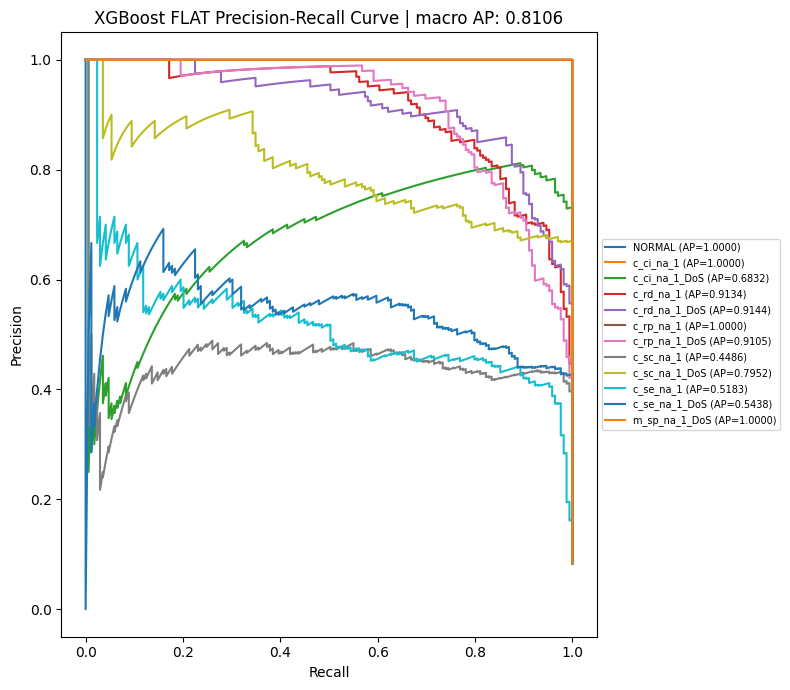

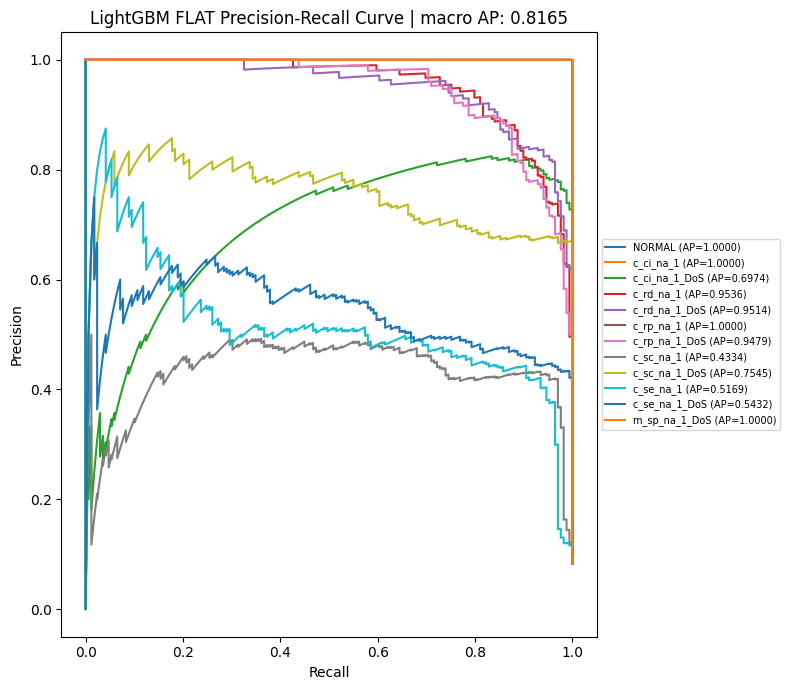

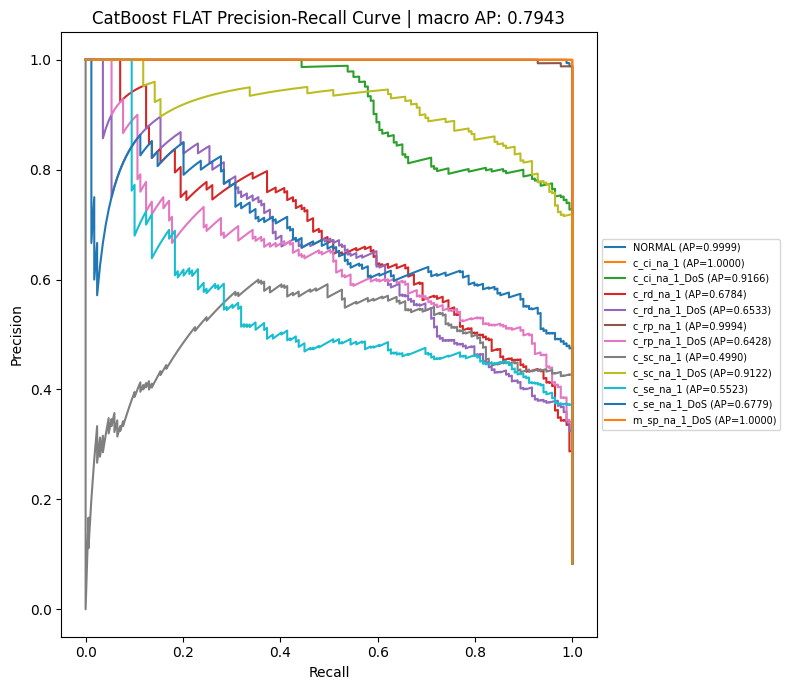

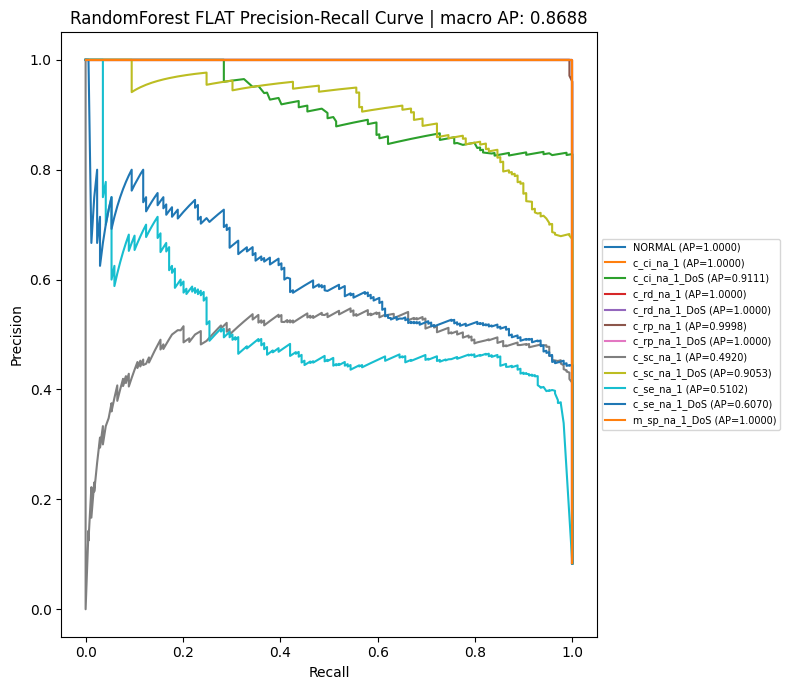

In [17]:
def pr_auc(model, X, y_true, enc, title):
    n = len(enc.classes_)
    y_bin = label_binarize(y_true, classes=range(n))
    proba = model.predict_proba(X)

    plt.figure(figsize=(8, 7))
    for i in range(n):
        precision, recall, _ = precision_recall_curve(y_bin[:, i], proba[:, i])
        ap = average_precision_score(y_bin[:, i], proba[:, i])
        plt.plot(recall, precision, label=f'{enc.classes_[i]} (AP={ap:.4f})')

    macro_ap = average_precision_score(y_bin, proba, average='macro')
    plt.title(f'{title} Precision-Recall Curve | macro AP: {macro_ap:.4f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)
    plt.tight_layout()
    plt.show()

functions(pr_auc)

# PR-AUC

### The Random Forest has a very good macro AP of 0.9913, with only c_ci_na_1_DoS at 0.9256 versus ~0.99 for the rest.

### The quad CatBoost model does not perform as well, with a macro AP of 0.7066. Thisplot is more informative than the ROC curve, which reports 0.9048 for the same model a gap of 0.20. The reason is that FPR divides false positives by the total number ofnegatives, so they appear small, while precision divides them by the number of positivepredictions, which makes their effect visible. The PR curve is therefore the stricter metric here.

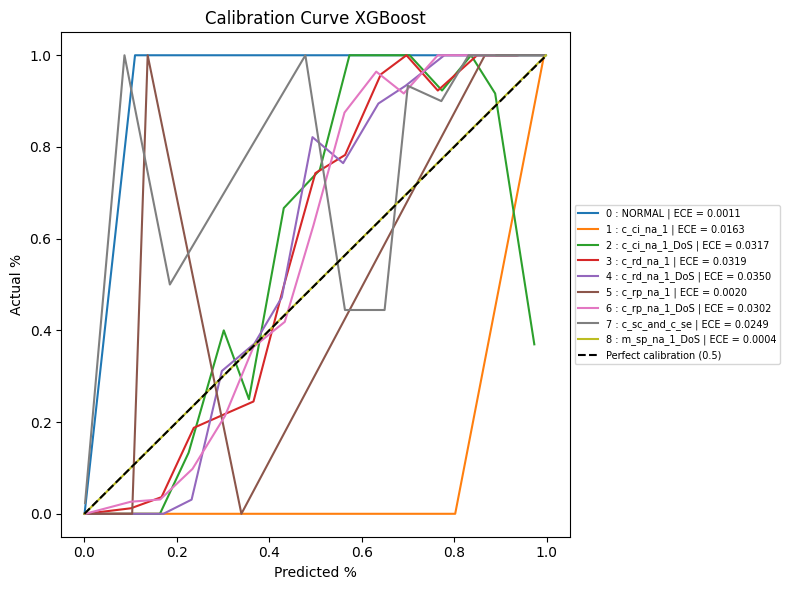

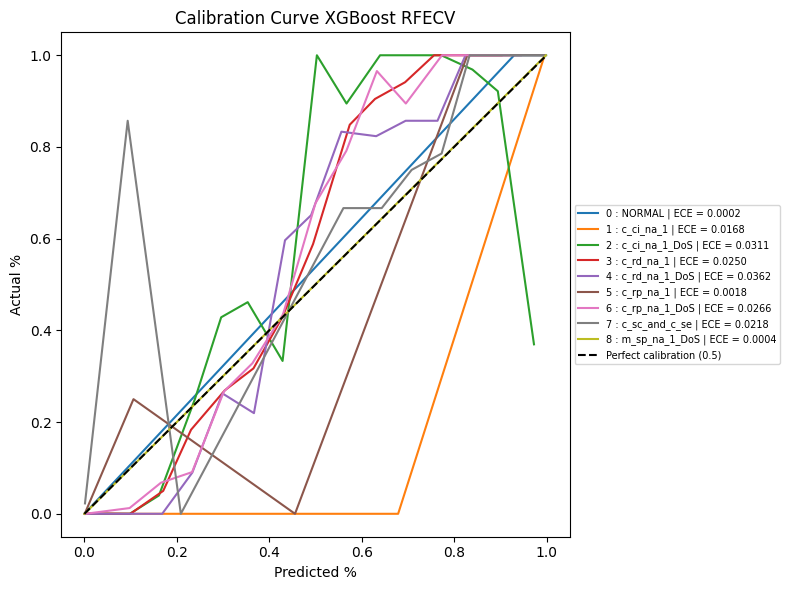

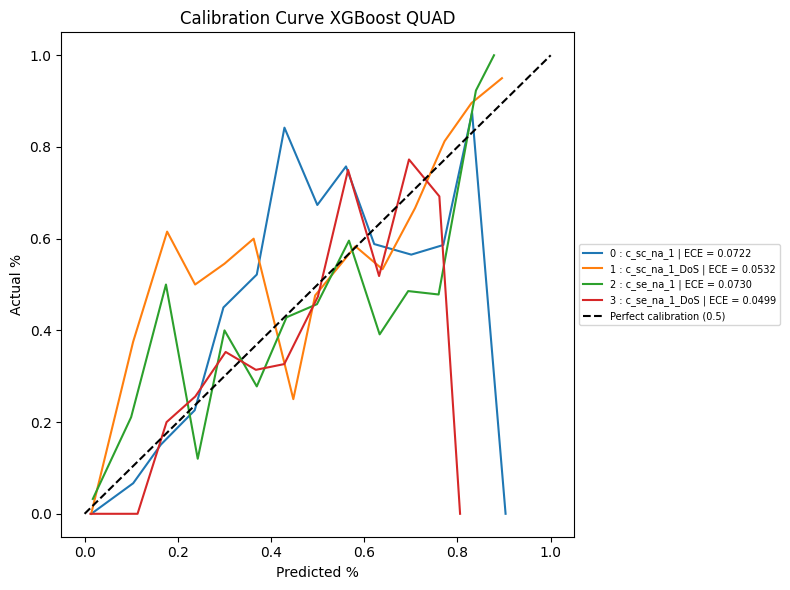

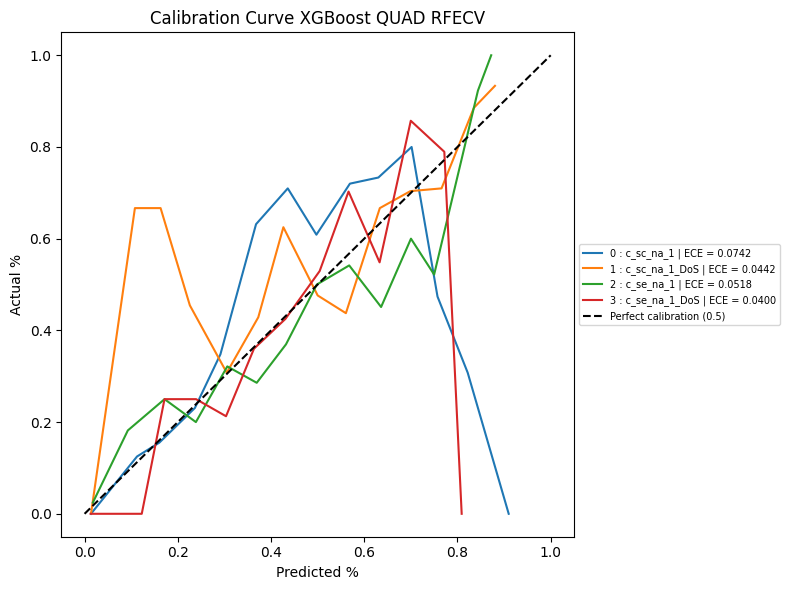

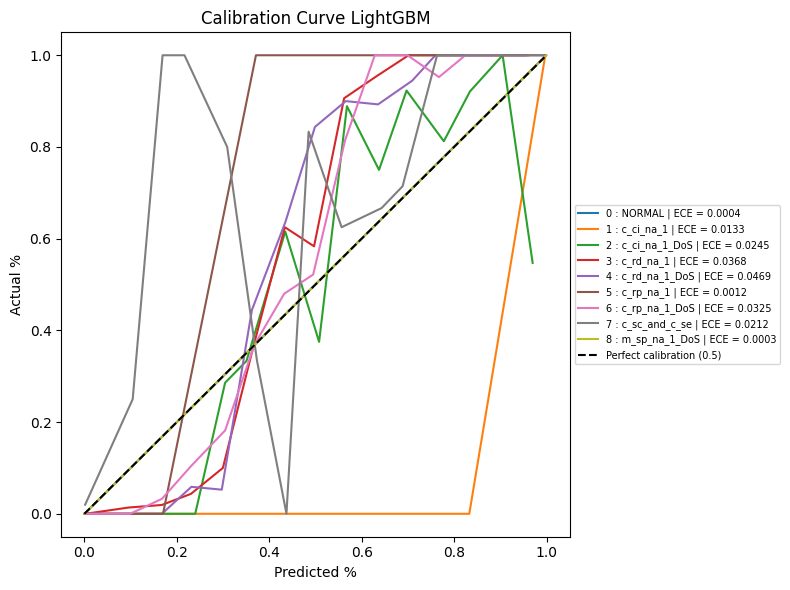

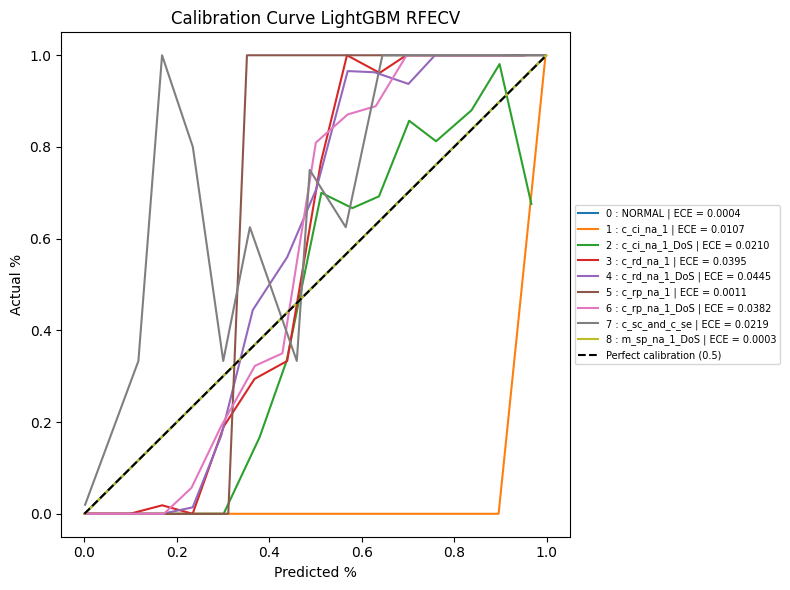

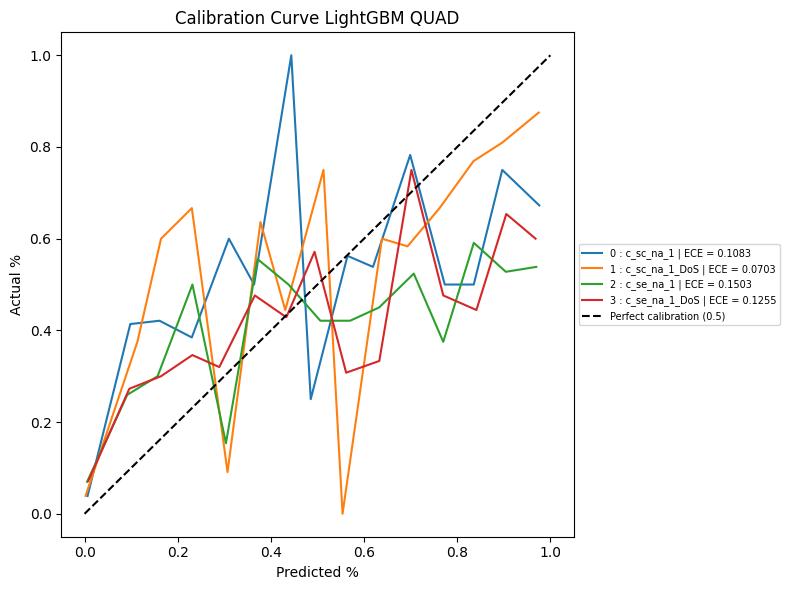

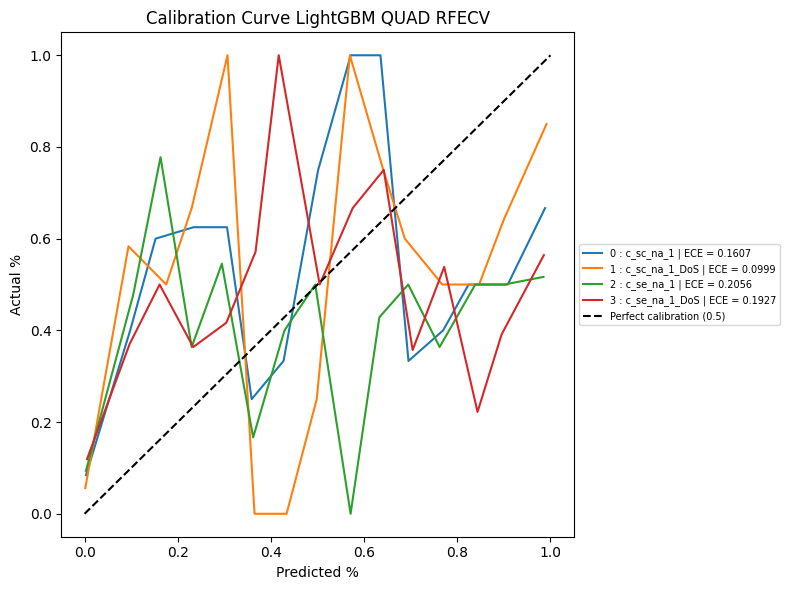

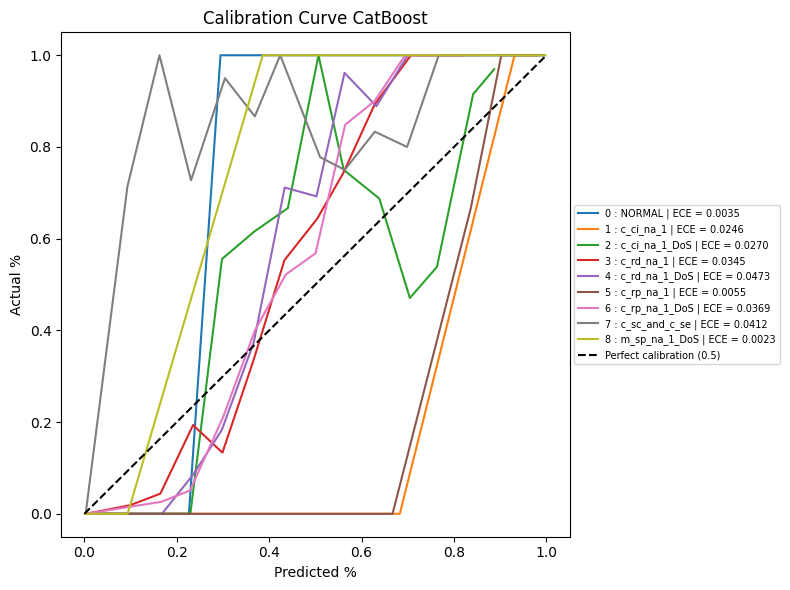

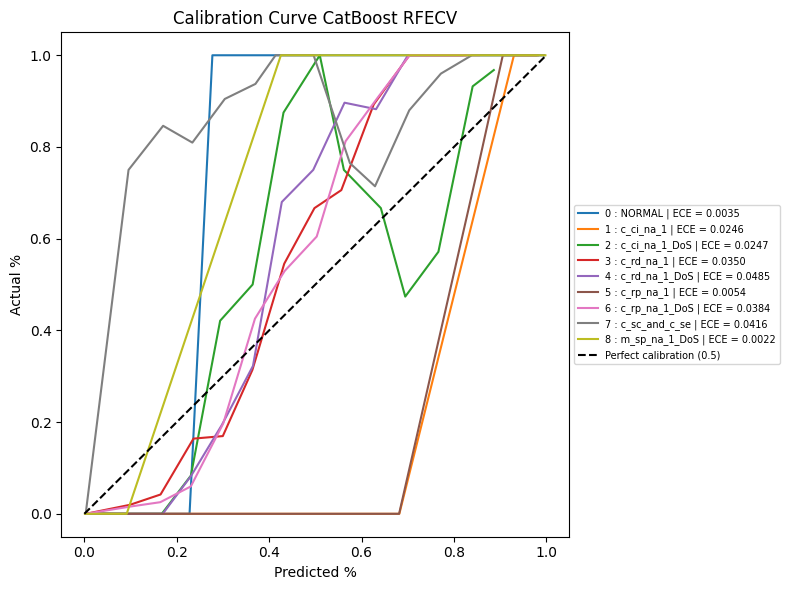

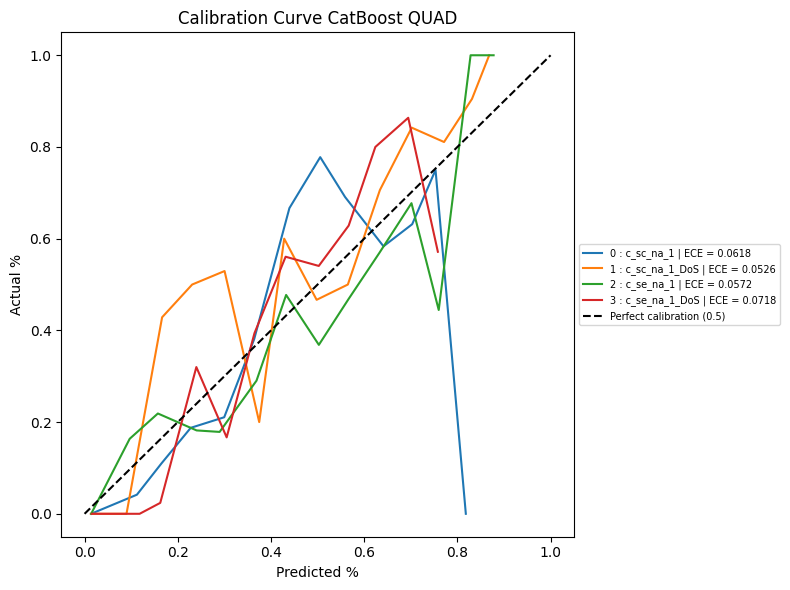

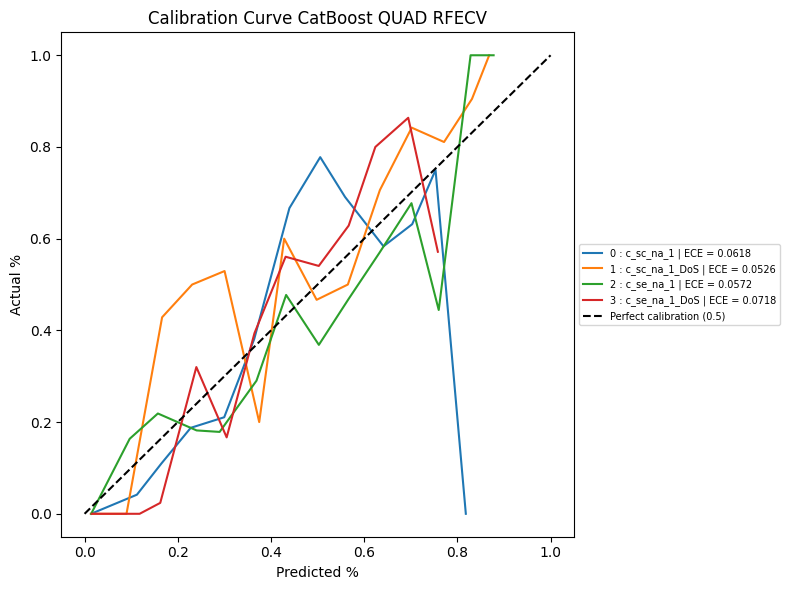

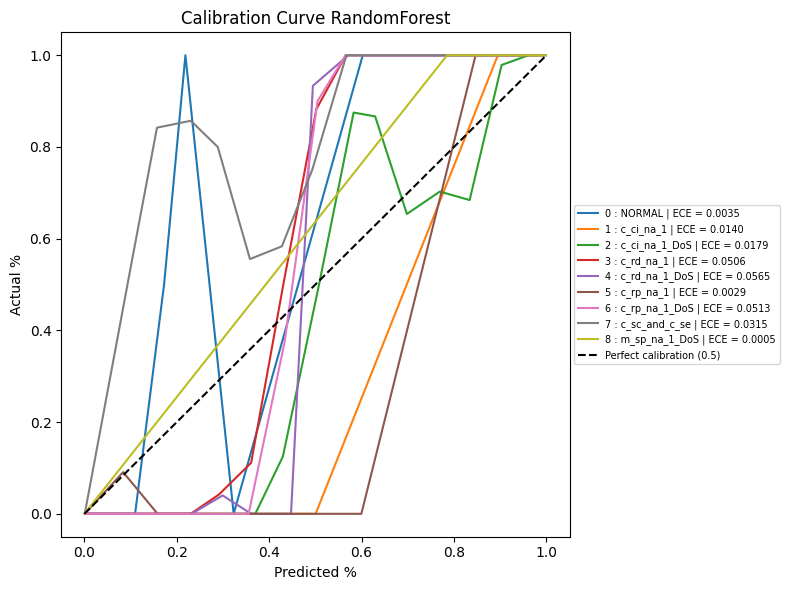

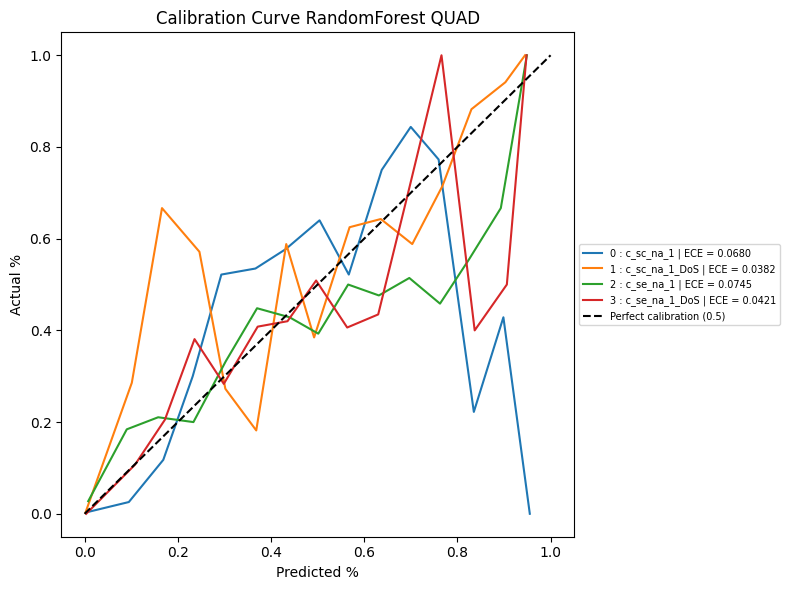

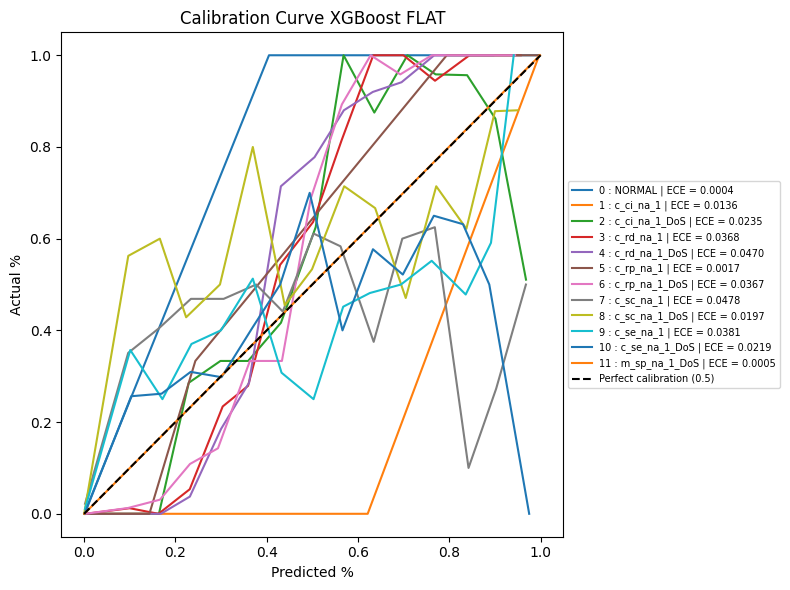

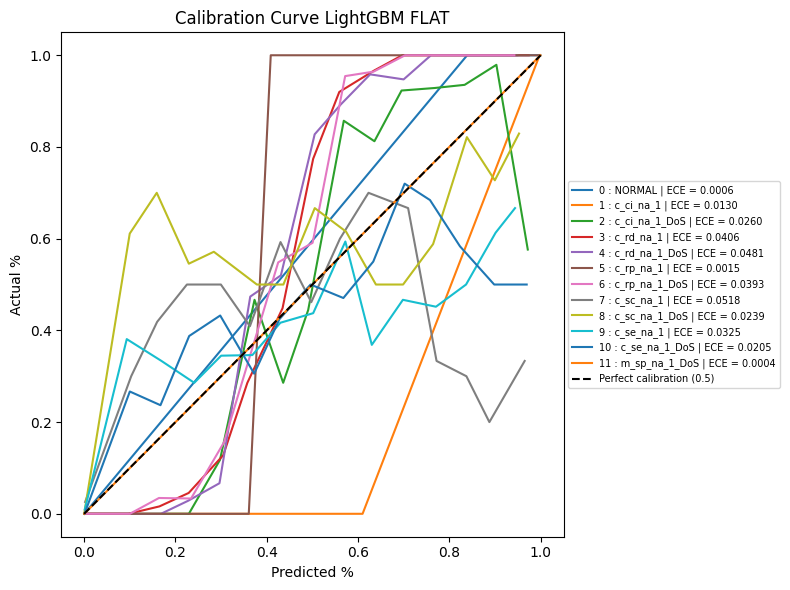

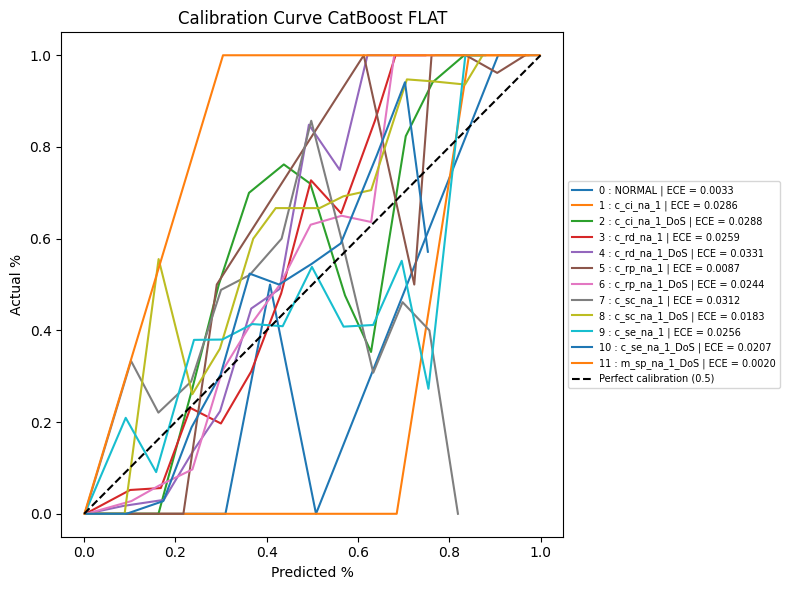

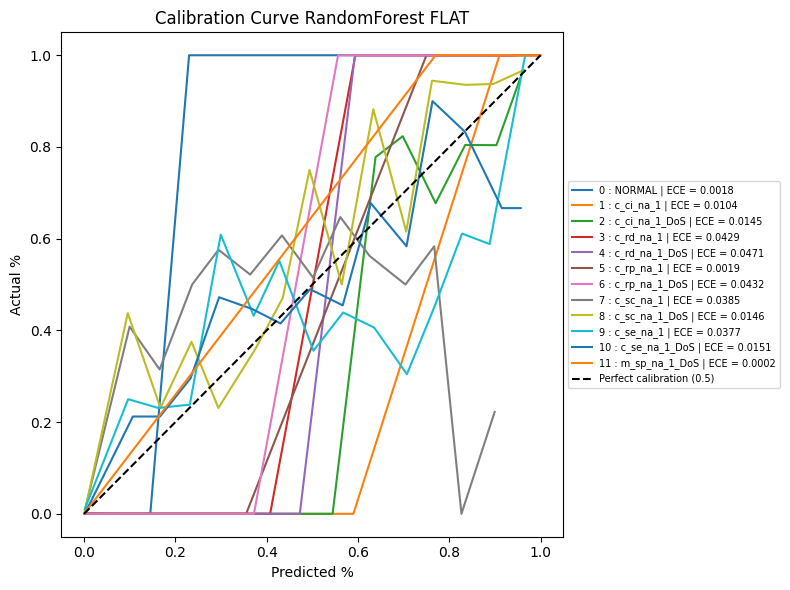

In [19]:
def Calibration_curve_models(model, X, y_true, enc, title):
    bins = 15
    edges = np.linspace(0, 1, bins + 1)
    plt.figure(figsize=(8, 6))
    for c in range(len(enc.classes_)):
        model_y_pred_proba = model.predict_proba(X)
        p = model_y_pred_proba[:, c]
        y = label_binarize(y_true, classes=range(len(enc.classes_)))[:, c]

        bin_index = np.clip(np.digitize(p, edges[1:-1]), 0, bins - 1)
        prob_pred, prob_true, weights_for_each_bin = [], [], []
        for b in range(bins):
            in_bin = bin_index == b
            if in_bin.sum() == 0:
                continue
            prob_pred.append(p[in_bin].mean())
            prob_true.append(y[in_bin].mean())
            weights_for_each_bin.append(in_bin.sum() / len(y_true))

        prob_pred = np.array(prob_pred)
        prob_true = np.array(prob_true)
        weights_for_each_bin = np.array(weights_for_each_bin)

        diff = np.abs(prob_true - prob_pred)
        ece = np.sum(diff * weights_for_each_bin)
        plt.plot(prob_pred, prob_true, label=f'{c} : {enc.classes_[c]} | ECE = {ece:.4f}')

    plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration (0.5)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)
    plt.xlabel('Predicted %')
    plt.ylabel('Actual %')
    plt.title(f'Calibration Curve {title}')
    plt.tight_layout()
    plt.show()

functions(Calibration_curve_models)

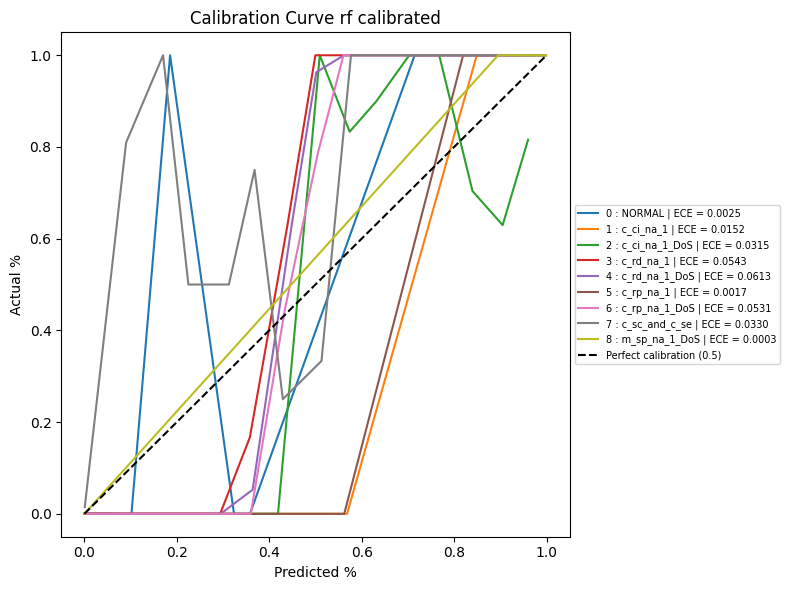

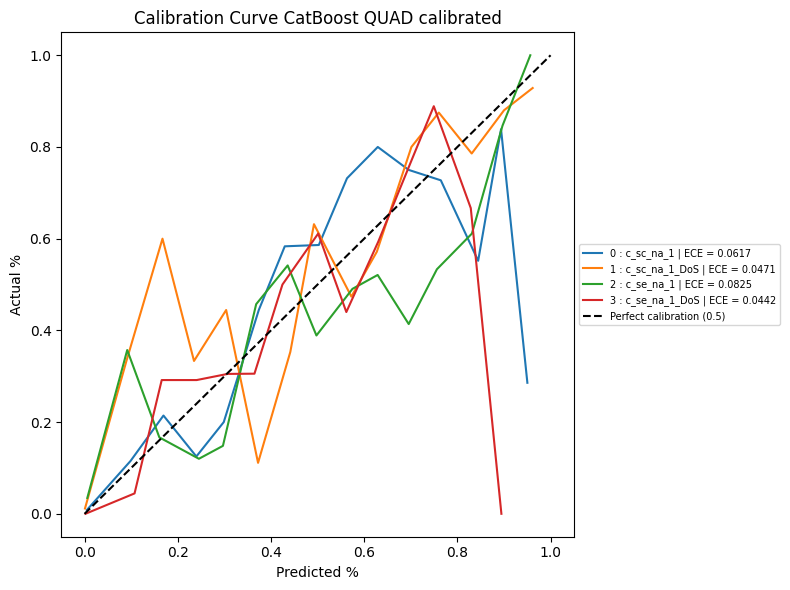

In [20]:
calibrated_rf=CalibratedClassifierCV(
        estimator=clone(rf_model),
        method='isotonic',
        cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
)
calibrated_rf.fit(X_train,y_train)


calibrated_CatBoost_quad=CalibratedClassifierCV(
        estimator=clone(Catboost_model_quad),
        method='isotonic',
        cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=63),
)
calibrated_CatBoost_quad.fit(X_train_quad,y_train_quad)
Calibration_curve_models(calibrated_rf, X_test, y_test, le, 'rf calibrated')
Calibration_curve_models(calibrated_CatBoost_quad, X_test_quad, y_test_quad, le_quad, 'CatBoost QUAD calibrated')

In [21]:
print(f'Calibrated rf model classification report: \n{classification_report(y_test,calibrated_rf.predict(X_test))}')
print(f'Calibrated CatBoost Quad model classification report: \n{classification_report(y_test_quad,calibrated_CatBoost_quad.predict(X_test_quad))}')

Calibrated rf model classification report: 
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       169
           1       0.99      1.00      1.00       169
           2       0.80      0.99      0.89       169
           3       0.99      0.98      0.99       169
           4       0.99      0.99      0.99       169
           5       0.99      0.99      0.99       169
           6       0.97      0.99      0.98       169
           7       1.00      0.93      0.96       676
           8       1.00      1.00      1.00       169

    accuracy                           0.97      2028
   macro avg       0.97      0.99      0.98      2028
weighted avg       0.98      0.97      0.97      2028

Calibrated CatBoost Quad model classification report: 
              precision    recall  f1-score   support

           0       0.69      0.79      0.74       169
           1       0.78      0.76      0.77       169
           2       0.53      0.63

# Calibration

Isotonic calibration (10-fold) was applied to both the Random Forest and the
CatBoost quad model to check whether their predicted probabilities could be
improved.

| Model | Mean ECE before | Mean ECE after | Accuracy before | Accuracy after |
| ----- | --------------- | -------------- | --------------- | -------------- |
| Random Forest (9 classes) | 0.0254 | 0.0281 | 0.98 | 0.97 |
| CatBoost quad (4 classes) | 0.0609 | 0.0540 | 0.68 | 0.66 |

### Random Forest
Already well calibrated before calibration. The easiest classes are almost
perfect (m_sp_na_1_DoS 0.0005, c_rp_na_1 0.0029, NORMAL 0.0035), while the
c_rd/c_rp classes have the highest error (~0.05). Isotonic regression made the
mean ECE slightly worse (0.0254 → 0.0281) and cost one point of accuracy.

### CatBoost quad
Roughly twice the calibration error of the Random Forest. Isotonic regression
improved the mean ECE (0.0609 → 0.0540), mostly on c_se_na_1_DoS
(0.0718 → 0.0379), but accuracy dropped from 0.68 to 0.66. None of the four
curves goes beyond a predicted probability of ~0.87, meaning the model is never
confident about these classes.

### Conclusion
Calibration did not help either model. The probabilities were already honest,
so there was no overconfidence to correct. The uncertainty in the sc/se family
comes from the features themselves, not from the way the model reports its
confidence.

In [22]:
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train, y_train,
    train_sizes=np.linspace(0.3, 1.0, 8),
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=63),
    scoring='f1_macro',
    n_jobs=-1
)


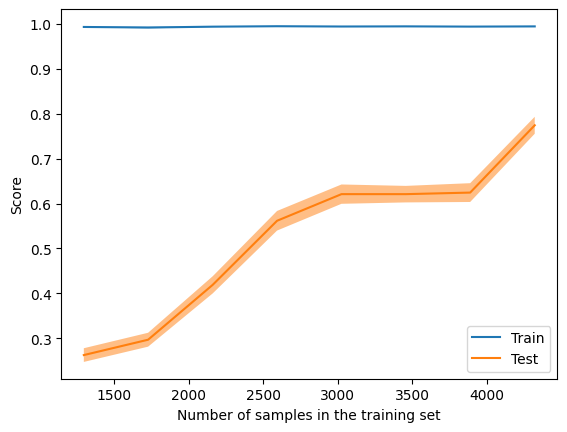

In [23]:
display=LearningCurveDisplay(train_sizes=train_sizes,train_scores=train_scores, test_scores=test_scores, score_name="Score")
display.plot()

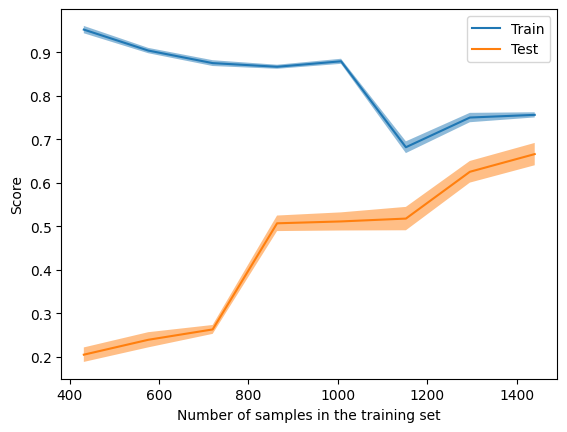

In [24]:
train_sizes, train_scores, test_scores = learning_curve(
    Catboost_model_quad, X_train_quad, y_train_quad,
    train_sizes=np.linspace(0.3, 1.0, 8),
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=63),
    scoring='f1_macro',
    n_jobs=1
)
display=LearningCurveDisplay(train_sizes=train_sizes,train_scores=train_scores, test_scores=test_scores, score_name="Score")
display.plot()

From the learning curve we understand that the model as the number of samples progresses it improves its accuracy so that means that more data maybe could help the model
The RF model near perfect training on the training score which means that it has memorized very well the data and as we see the learning curve gets better at the last 500 samples which explains why the model is getting better scores at the test set rather than the CV set from the gridsearchCV because it never reaches to more data.
The learning curve on the quad model can't say the same.The test score increases over the number of training samples but the train score decreases and that suggests they would converge and have a tradeoff near at 0.65 if the number of samples progresses and they will plateau.

In [25]:
reducer=umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
scaler=StandardScaler()
Scaled_data=scaler.fit_transform(X_data)
embeding=reducer.fit_transform(Scaled_data)


c:\Users\giorg\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [26]:
quad_reducer=umap.UMAP(n_neighbors=30,min_dist=0.1,random_state=42)
scaled_data_quad=scaler.fit_transform(X_data_quad)
embeding_quad=quad_reducer.fit_transform(scaled_data_quad)

c:\Users\giorg\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


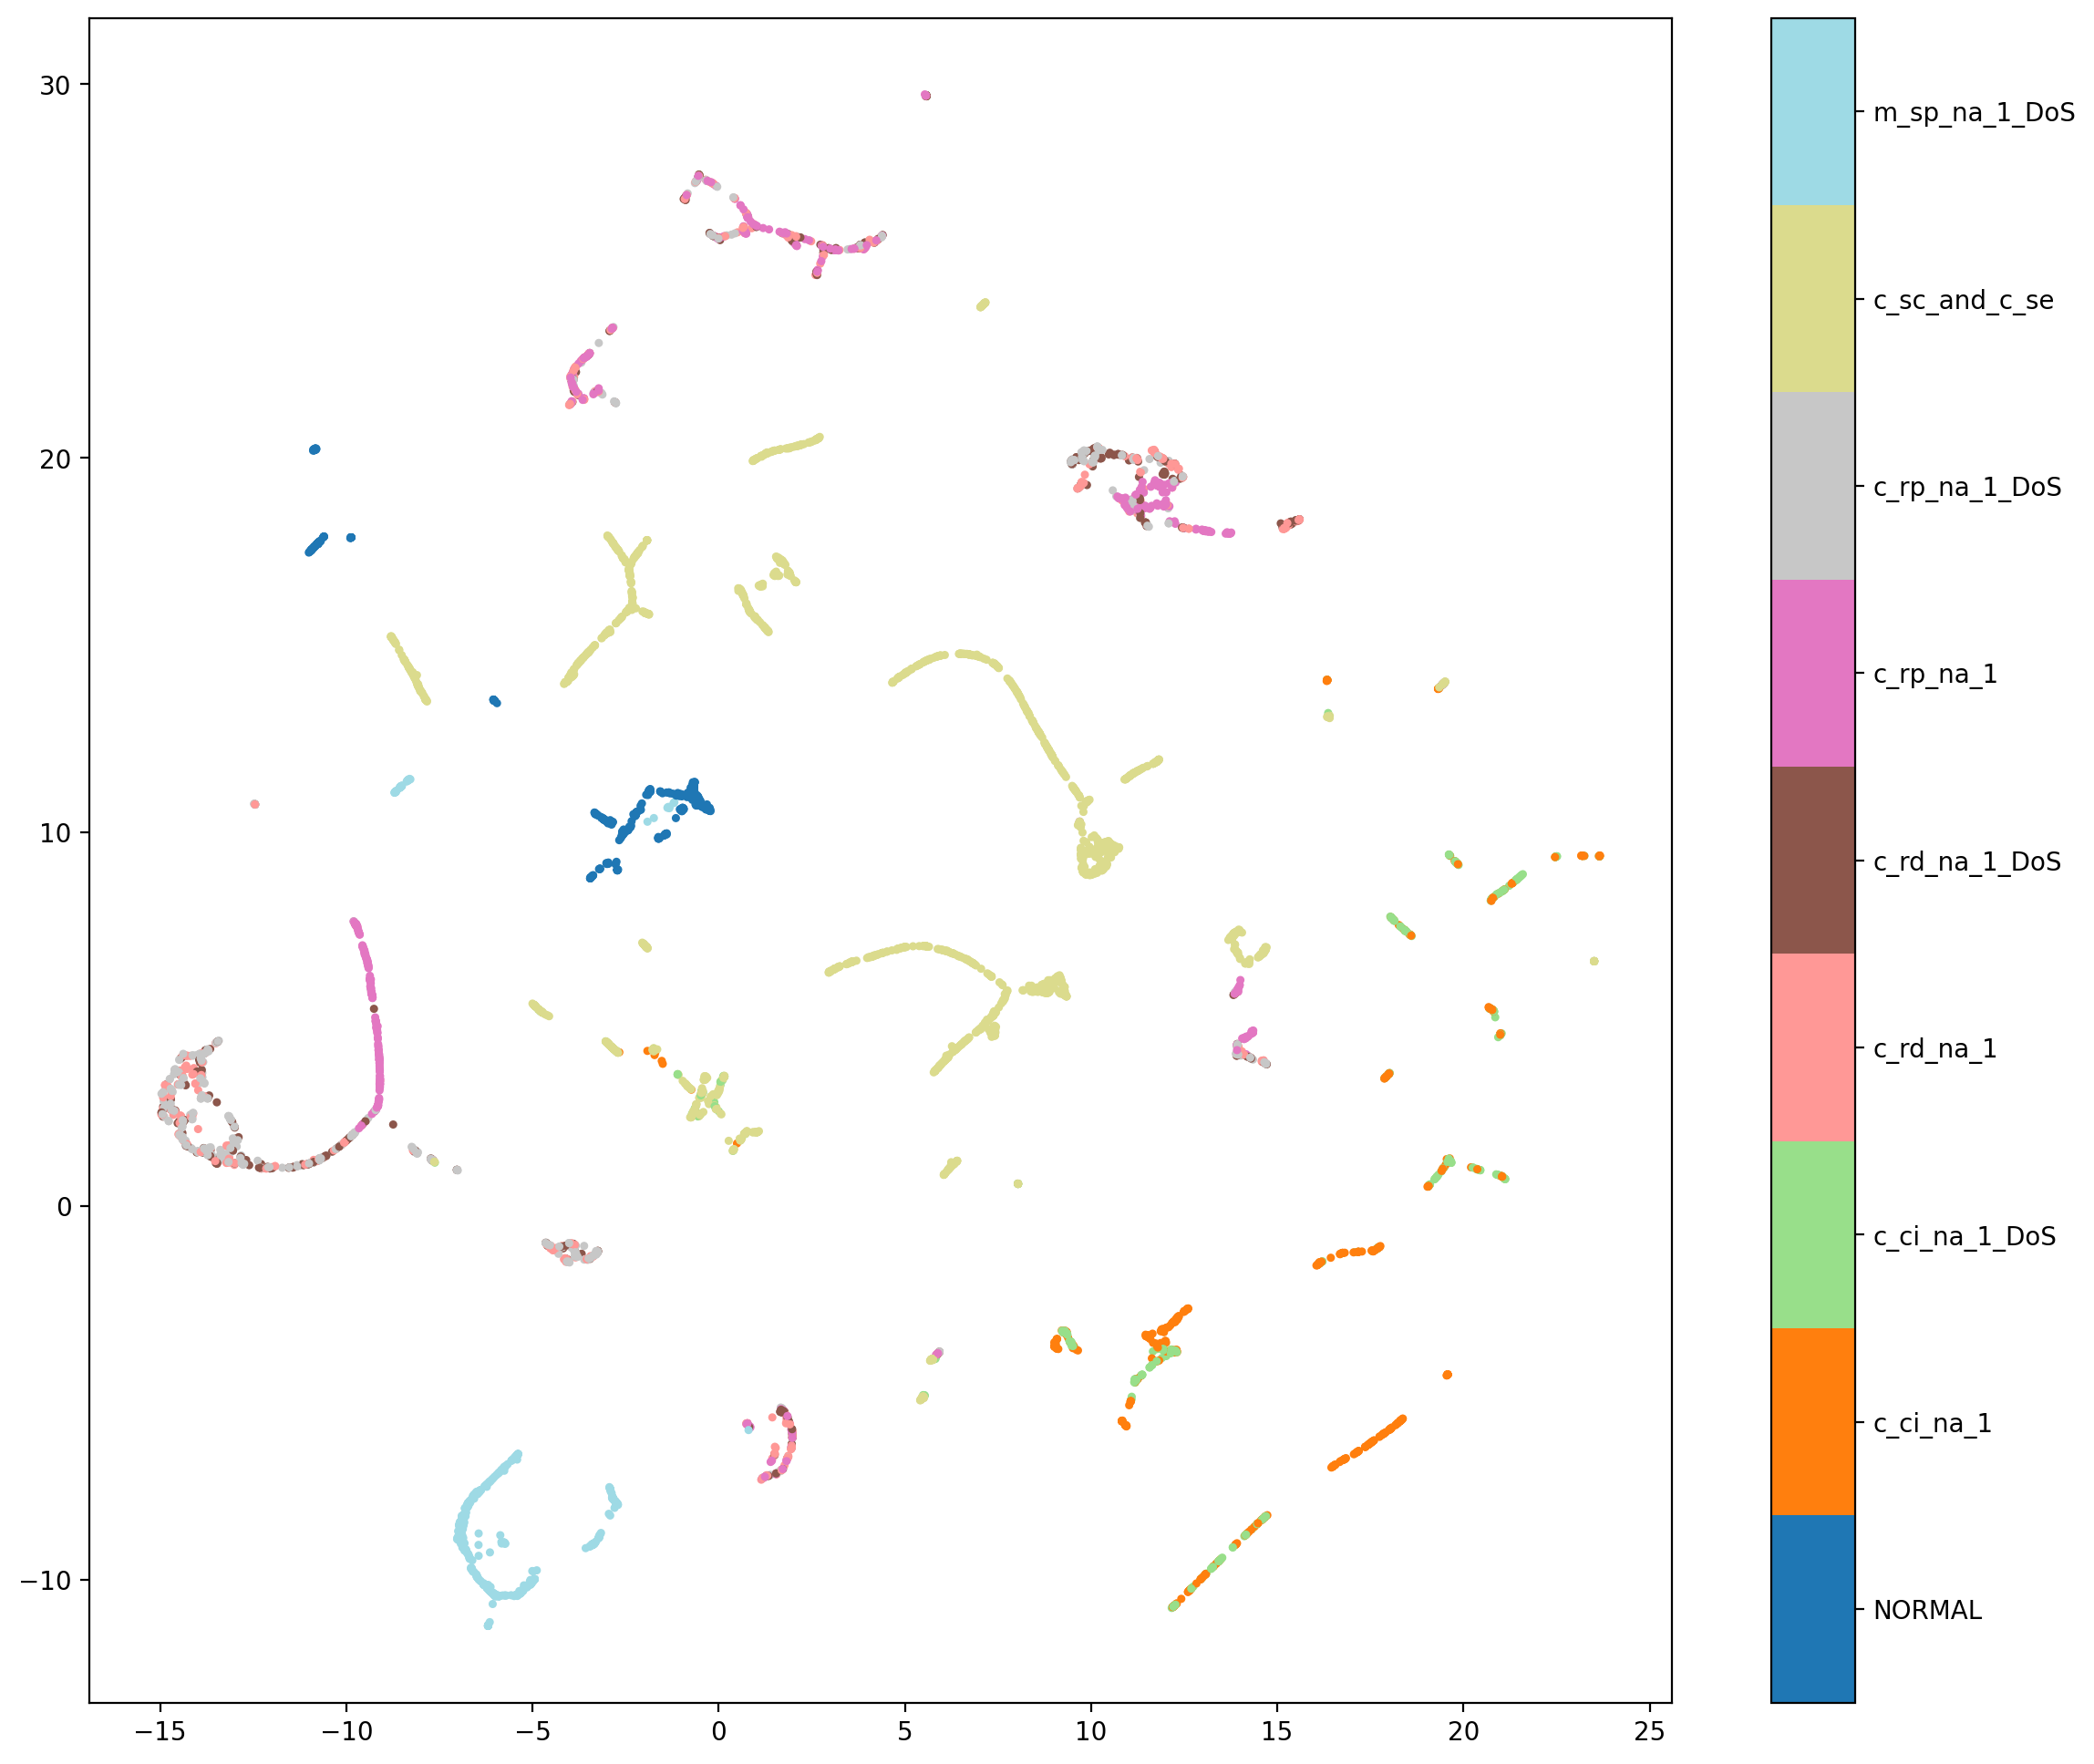

In [27]:
plt.figure(figsize=(14,12),dpi=200)
sc=plt.scatter(embeding[:,0],embeding[:,1],c=y_data,cmap='tab20',s=5,alpha=1)
cbar = plt.colorbar(sc, boundaries=np.arange(class_range + 1) - 0.5)
cbar.set_ticks(np.arange(class_range))
cbar.set_ticklabels(le.classes_)
plt.show()

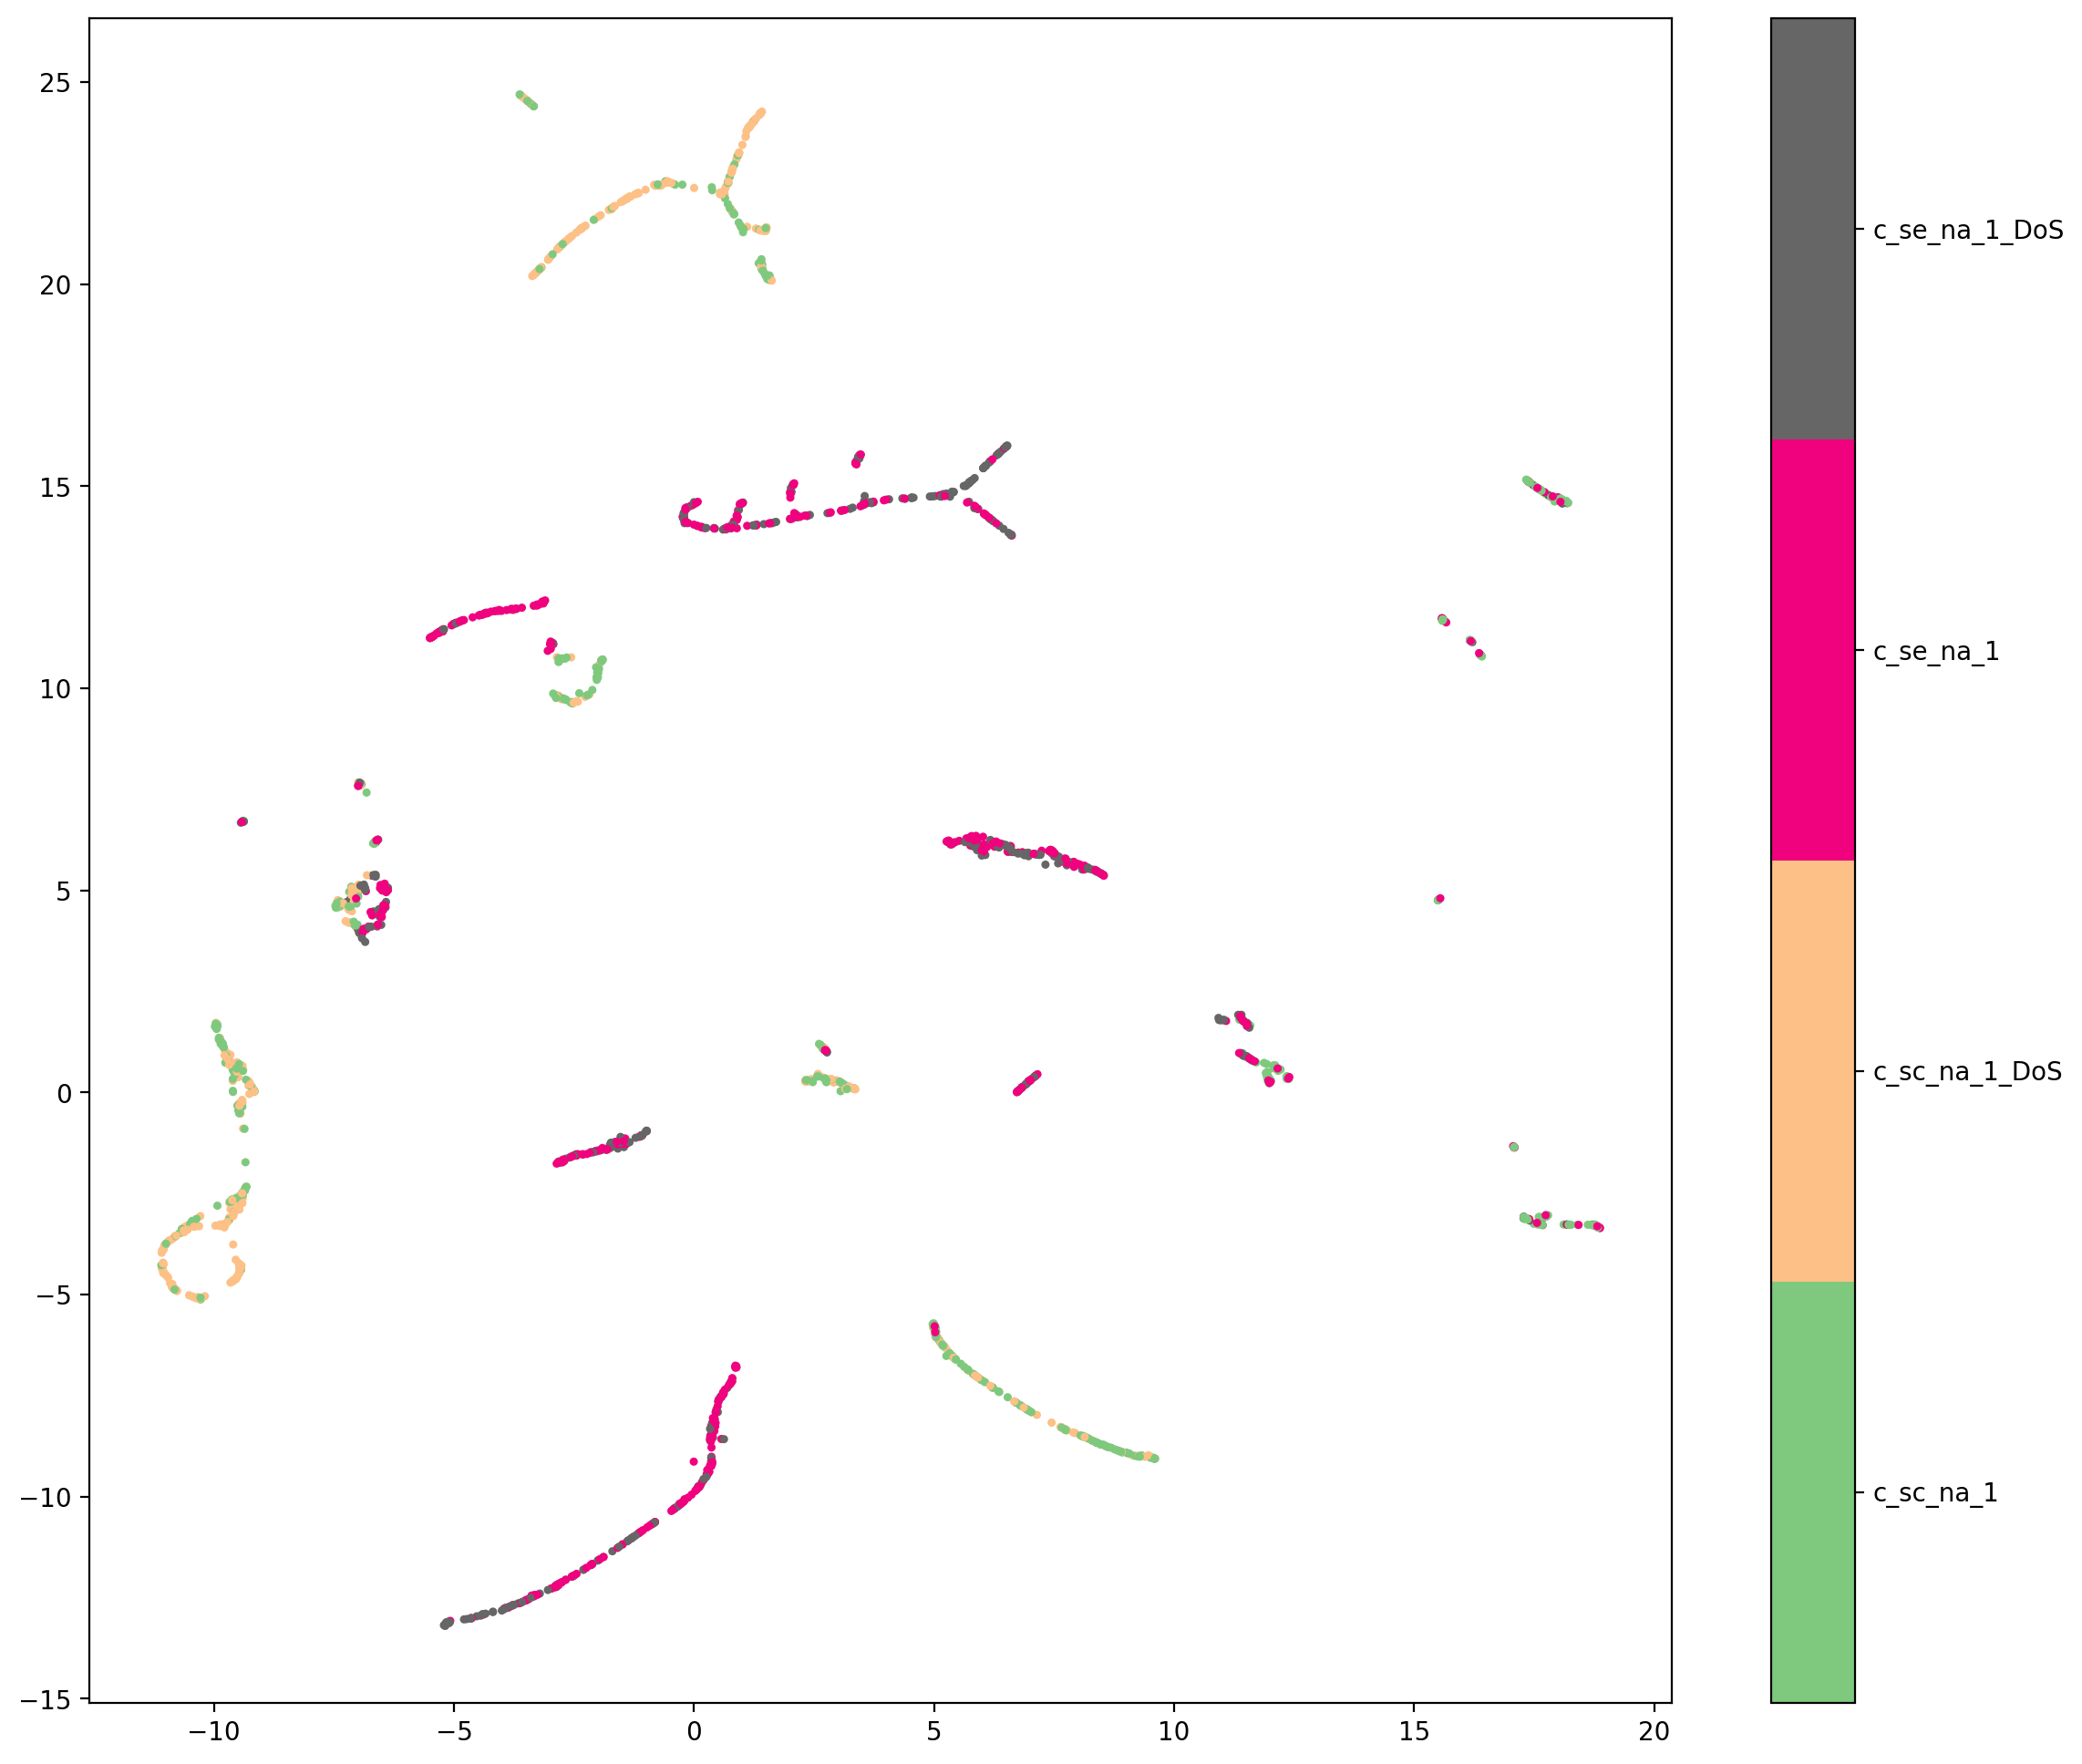

In [28]:
plt.figure(figsize=(14,12),dpi=200)
sc=plt.scatter(embeding_quad[:,0],embeding_quad[:,1],c=y_data_quad,cmap='Accent',s=5,alpha=1)
cbar = plt.colorbar(sc, boundaries=np.arange(4+ 1) - 0.5)
cbar.set_ticks(np.arange(4))
cbar.set_ticklabels(le_quad.classes_)
plt.show()

# UMAP

### In the UMAP projection of the 9-class feature space, most classes form distinct clusters. NORMAL (blue) and m_sp_na_1_DoS (light blue) are cleanly separated from the rest, and c_sc_and_c_se (yellow) occupies its own set of regions. The c_rd/c_rp classes and their DoS variants are the most mixed, sharing the same place on the left side of the projection. Despite this, they achieve high F1 scores. UMAP reduces the feature space to two dimensions, so overlap in the projection does not mean the classes are inseparable in the original 111 features; as we saw from the SHAP plots, the model relies on secondary features to tell these classes apart.

### For the quad family, the four classes (c_sc_na_1, c_sc_na_1_DoS, c_se_na_1, c_se_na_1_DoS) mostly do not sit all together throughout the projection; instead each one groups with its own variant, though there are some places where all four sit together. The c_sc classes are more separated from each other, while the c_se classes are more squeezed together, which explains why the models make more accurate predictions on the c_sc classes and less accurate ones on the c_se classes.

In [15]:
def run_models(model, X, y_true, enc, title):
    print(f"{title} classification report:\n")
    print(classification_report(y_true, np.asarray(model.predict(X)).ravel(),
                                target_names=enc.classes_))
functions(run_models)


XGBoost classification report:

               precision    recall  f1-score   support

       NORMAL       1.00      0.99      1.00       169
    c_ci_na_1       0.97      1.00      0.98       169
c_ci_na_1_DoS       0.80      0.89      0.85       169
    c_rd_na_1       0.75      0.77      0.76       169
c_rd_na_1_DoS       0.78      0.73      0.75       169
    c_rp_na_1       1.00      0.99      1.00       169
c_rp_na_1_DoS       0.75      0.78      0.77       169
c_sc_and_c_se       0.98      0.94      0.96       676
m_sp_na_1_DoS       1.00      1.00      1.00       169

     accuracy                           0.91      2028
    macro avg       0.89      0.90      0.90      2028
 weighted avg       0.91      0.91      0.91      2028

XGBoost RFECV classification report:

               precision    recall  f1-score   support

       NORMAL       1.00      0.99      1.00       169
    c_ci_na_1       0.96      1.00      0.98       169
c_ci_na_1_DoS       0.81      0.89      0.85  

RFECV reduced the feature set to 36 features for XGBoost and 26 for its quad variant, while CatBoost retained all 111. Test performance changed by at most 0.01 in accuracy and macro-F1 for every model, indicating that the information is distributed across correlated features rather than concentrated in a small subset.

In [16]:
X_train_anomaly=trainDf[trainDf['Label']=='NORMAL']
X_train_anomaly=X_train_anomaly.drop('Label',axis=1)
X_test_anomaly=testDf.drop('Label',axis=1)
y_test_anomaly=testDf['Label'].apply(lambda label:1 if label=='NORMAL'else -1)

from sklearn.ensemble import IsolationForest
ilf_model=IsolationForest(
    n_estimators=100,
    contamination=0.033,
    random_state=63
)
ilf_model.fit(X_train_anomaly)
y_pred_anomaly=ilf_model.predict(X_test_anomaly)
print(classification_report(y_test_anomaly,ilf_model.predict(X_test_anomaly),labels=[-1, 1],
    target_names=['Attack', 'Normal']))


              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      1859
      Normal       1.00      0.99      0.99       169

    accuracy                           1.00      2028
   macro avg       1.00      0.99      1.00      2028
weighted avg       1.00      1.00      1.00      2028



In [17]:
anomaly_mask=y_pred_anomaly==-1
y_pred_final=pd.Series('NORMAL',index=X_test.index)
X_rf=X_test[anomaly_mask]
y_rf_pred=rf_model.predict(X_rf)
y_pred_final.loc[X_rf.index]=le.inverse_transform(y_rf_pred)
quad_mask=y_rf_pred==7
X_cat=X_rf[quad_mask]
y_cat_pred=Catboost_model_quad.predict(X_cat).ravel()
y_pred_final.loc[X_cat.index]=le_quad.inverse_transform(y_cat_pred)
print(classification_report(le_un.inverse_transform(y_test_un),y_pred_final))

               precision    recall  f1-score   support

       NORMAL       1.00      0.99      1.00       169
    c_ci_na_1       0.99      1.00      1.00       169
c_ci_na_1_DoS       0.81      0.99      0.89       169
    c_rd_na_1       0.99      0.98      0.98       169
c_rd_na_1_DoS       0.98      1.00      0.99       169
    c_rp_na_1       0.99      0.99      0.99       169
c_rp_na_1_DoS       0.99      0.99      0.99       169
    c_sc_na_1       0.68      0.60      0.64       169
c_sc_na_1_DoS       0.80      0.78      0.79       169
    c_se_na_1       0.55      0.66      0.60       169
c_se_na_1_DoS       0.66      0.47      0.55       169
m_sp_na_1_DoS       1.00      1.00      1.00       169

     accuracy                           0.87      2028
    macro avg       0.87      0.87      0.87      2028
 weighted avg       0.87      0.87      0.87      2028



In [18]:
y_pred_final_enc=le_un.transform(y_pred_final)

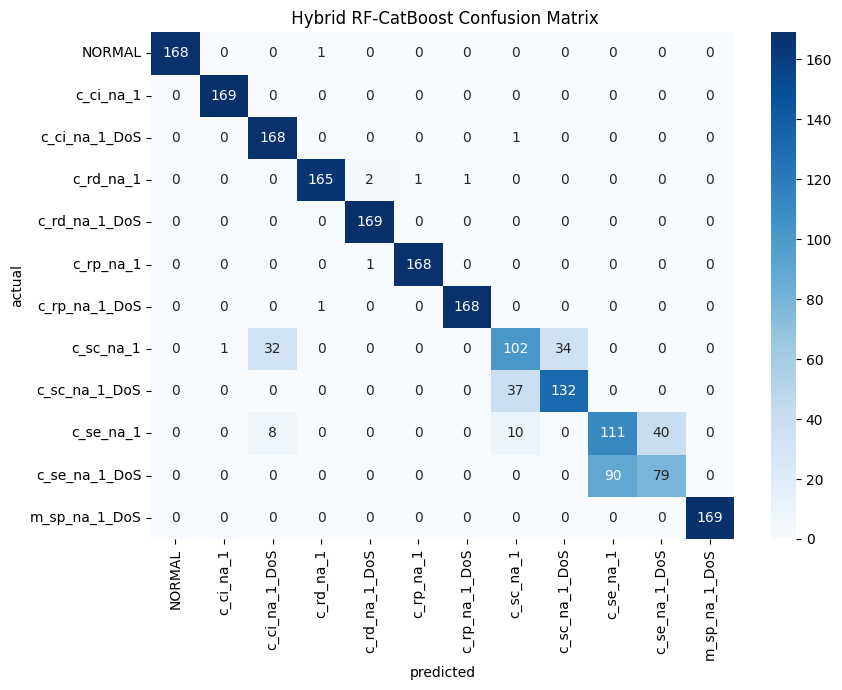

In [19]:
cm=confusion_matrix(y_test_un,y_pred_final_enc)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_un.classes_, yticklabels=le_un.classes_)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title(' Hybrid RF-CatBoost Confusion Matrix')
plt.tight_layout()
plt.show()


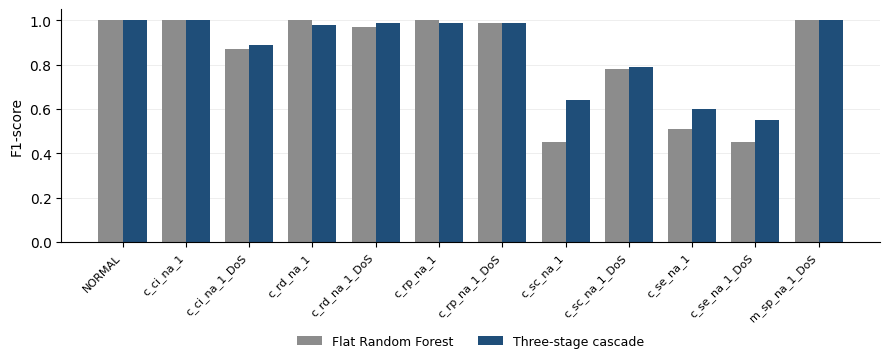

In [58]:
classes = ['NORMAL','c_ci_na_1','c_ci_na_1_DoS','c_rd_na_1','c_rd_na_1_DoS',
           'c_rp_na_1','c_rp_na_1_DoS','c_sc_na_1','c_sc_na_1_DoS',
           'c_se_na_1','c_se_na_1_DoS','m_sp_na_1_DoS']

flat    = [1.00,1.00,0.87,1.00,0.97,1.00,0.99,0.45,0.78,0.51,0.45,1.00]
cascade = [1.00,1.00,0.89,0.98,0.99,0.99,0.99,0.64,0.79,0.60,0.55,1.00]

x = np.arange(len(classes))
w = 0.38

fig, ax = plt.subplots(figsize=(9,4))
ax.bar(x - w/2, flat,    w, label='Flat Random Forest', color='#8c8c8c')
ax.bar(x + w/2, cascade, w, label='Three-stage cascade', color='#1f4e79')

ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)                    # άξονας από το μηδέν
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax.legend(frameon=True, facecolor='white', framealpha=0.95,
          edgecolor='none', loc='upper center',
          bbox_to_anchor=(0.5, -0.35), ncol=2, fontsize=9)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linewidth=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig_per_class_f1.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def timeit(fn, repeats=20):
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        ts.append(time.perf_counter() - t0)
    return np.mean(ts) * 1000
def cascade_predict():
    y_pred_anomaly = ilf_model.predict(X_test_anomaly)
    anomaly_mask = y_pred_anomaly == -1
    y_pred_final = pd.Series('NORMAL', index=X_test.index)
    X_rf = X_test[anomaly_mask]
    y_rf_pred = rf_model.predict(X_rf)
    y_pred_final.loc[X_rf.index] = le.inverse_transform(y_rf_pred)
    quad_mask = y_rf_pred == 7
    X_cat = X_rf[quad_mask]
    y_cat_pred = Catboost_model_quad.predict(X_cat).ravel()
    y_pred_final.loc[X_cat.index] = le_quad.inverse_transform(y_cat_pred)
    return y_pred_final

def flat_predict():
    return flat_rf.predict(X_test)

flat_ms = timeit(flat_predict)
casc_ms = timeit(cascade_predict)         

print(f'Flat RF:  {flat_ms:.2f} ms')
print(f'Cascade:  {casc_ms:.2f} ms')
print(f'per flow: {casc_ms/2028*1000:.2f} μs')

Flat RF:  31.00 ms
Cascade:  37.89 ms
per flow: 18.68 μs
